<a href="https://colab.research.google.com/github/Kenduiwo/kenduiwo/blob/main/Uganda_kiva_loan_analysis_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
sns.set(color_codes=True)

In [ ]:
kiva=pd.read_csv('/content/drive/MyDrive/kiva_loans.csv')
kiva_themes=pd.read_csv('/content/drive/MyDrive/loan_theme_ids.csv')
kiva_themes_region=pd.read_csv('/content/drive/MyDrive/loan_themes_by_region.csv')

In [ ]:
mpi=pd.read_csv('/content/drive/MyDrive/kiva_mpi_region_locations.csv')

In [ ]:
kiva.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01


In [ ]:
kiva_themes.head(2)

,id,Loan Theme ID,Loan Theme Type,Partner ID
0,638631,a1050000000skGl,General,151.0
1,640322,a1050000000skGl,General,151.0


In [ ]:
kiva_themes_region.head(2)

,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,9,KREDIT Microfinance Institution,General Financial Inclusion,a1050000000slfi,Higher Education,Cambodia,No,Banteay Meanchey,"(13.75, 103.0)",KHM,...,450,"Banteay Meanchey, Cambodia","[(13.6672596, 102.8975098)]",Banteay Meanchey Province; Cambodia,"(13.6672596, 102.8975098)",13.667260,102.897510,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0
1,9,KREDIT Microfinance Institution,General Financial Inclusion,a10500000068jPe,Vulnerable Populations,Cambodia,No,Battambang Province,NaN,KHM,...,20275,"Battambang Province, Cambodia","[(13.0286971, 102.989615)]",Battambang Province; Cambodia,"(13.0286971, 102.989615)",13.028697,102.989615,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0


In [ ]:
mpi.head(2)

,LocationName,ISO,country,region,world_region,MPI,geo,lat,lon
0,"Badakhshan, Afghanistan",AFG,Afghanistan,Badakhshan,South Asia,0.387,"(36.7347725, 70.81199529999999)",36.734772,70.811995
1,"Badghis, Afghanistan",AFG,Afghanistan,Badghis,South Asia,0.466,"(35.1671339, 63.7695384)",35.167134,63.769538


In [ ]:
kiva.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   use                 666973 non-null  object 
 6   country_code        671197 non-null  object 
 7   country             671205 non-null  object 
 8   region              614405 non-null  object 
 9   currency            671205 non-null  object 
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  object 
 12  disbursed_time      668809 non-null  object 
 13  funded_time         622874 non-null  object 
 14  term_in_months      671205 non-null  float64
 15  lender_count        671205 non-nul

In [ ]:
kiva.describe()

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,6.712050e+05,671205.000000,671205.000000,657698.000000,671205.000000,671205.000000
mean,9.932486e+05,785.995061,842.397107,178.199616,13.739022,20.590922
std,1.966113e+05,1130.398941,1198.660073,94.247581,8.598919,28.459551
min,6.530470e+05,0.000000,25.000000,9.000000,1.000000,0.000000
25%,8.230720e+05,250.000000,275.000000,126.000000,8.000000,7.000000
50%,9.927800e+05,450.000000,500.000000,145.000000,13.000000,13.000000
75%,1.163653e+06,900.000000,1000.000000,204.000000,14.000000,24.000000
max,1.340339e+06,100000.000000,100000.000000,536.000000,158.000000,2986.000000


In [ ]:
kiva.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,4232
country_code,8
country,0
region,56800
currency,0


In [ ]:
kiva.duplicated().sum()

0

In [ ]:
#subsetting to country Uganda
uganda=kiva[kiva['country']=='Uganda'].reset_index(drop=True)

In [ ]:
uganda.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653954,100.0,100.0,Home Energy,Personal Use,to pay for a cooking gas package so that he ca...,UG,Uganda,Bulenga - Nankwandde,UGX,343.0,2014-01-05 22:16:53+00:00,2013-12-12 08:00:00+00:00,2014-01-08 00:29:31+00:00,9.0,4,NaN,male,irregular,2014-01-05
1,653953,100.0,100.0,Home Energy,Personal Use,to pay for a package of clean energy so that h...,UG,Uganda,Namulanda - Off Entebbe Road,UGX,343.0,2014-01-05 21:53:00+00:00,2013-12-23 08:00:00+00:00,2014-01-07 16:41:34+00:00,7.0,1,NaN,male,irregular,2014-01-05


In [ ]:
uganda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20601 entries, 0 to 20600
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20601 non-null  int64  
 1   funded_amount       20601 non-null  float64
 2   loan_amount         20601 non-null  float64
 3   activity            20601 non-null  object 
 4   sector              20601 non-null  object 
 5   use                 20390 non-null  object 
 6   country_code        20601 non-null  object 
 7   country             20601 non-null  object 
 8   region              20390 non-null  object 
 9   currency            20601 non-null  object 
 10  partner_id          20601 non-null  float64
 11  posted_time         20601 non-null  object 
 12  disbursed_time      20601 non-null  object 
 13  funded_time         18249 non-null  object 
 14  term_in_months      20601 non-null  float64
 15  lender_count        20601 non-null  int64  
 16  tags

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [ ]:
#checking for missing values
uganda.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,211
country_code,0
country,0
region,211
currency,0


In [ ]:
#filling missing values with n_a since it is not affecting the columns of concern
uganda.fillna('n_a',inplace=True)

In [ ]:
uganda.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country_code,0
country,0
region,0
currency,0


In [ ]:
uganda.duplicated().sum()

0

In [ ]:
uganda_2=kiva_themes_region[kiva_themes_region['country']=='Uganda'].reset_index(drop=True)

In [ ]:
uganda_2.head(2)

,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,65,BRAC Uganda,General Financial Inclusion,a1050000000wezZ,General,Uganda,No,Abaita Ababiri,NaN,UGA,...,1125,"Abaita Ababiri, Uganda","[(0.09353349999999999, 32.4990828)]",Abayita Ababiri; Lyamutundwe; Wakiso; Central ...,"(0.09353349999999999, 32.4990828)",0.093534,32.499083,"West Nile, Uganda","(0.3157239, 32.575568)",70.0
1,65,BRAC Uganda,General Financial Inclusion,a1050000000sg1c,Youth,Uganda,No,Abaita Ababiri,NaN,UGA,...,850,"Abaita Ababiri, Uganda","[(0.09353349999999999, 32.4990828)]",Abayita Ababiri; Lyamutundwe; Wakiso; Central ...,"(0.09353349999999999, 32.4990828)",0.093534,32.499083,"West Nile, Uganda","(0.3157239, 32.575568)",70.0


In [ ]:
uganda['funded_amount']==uganda['loan_amount']

,0
0,True
1,True
2,True
3,True
4,True
...,...
20596,True
20597,False
20598,False
20599,False


In [ ]:
uganda['sector']==uganda['activity']

,0
0,False
1,False
2,False
3,False
4,False
...,...
20596,False
20597,False
20598,True
20599,True


In [ ]:
uganda.describe()

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,2.060100e+04,20601.000000,20601.000000,20601.000000,20601.000000,20601.000000
mean,9.364179e+05,686.504296,747.019562,171.234163,11.589729,19.448182
std,1.923710e+05,878.541681,992.302278,65.328835,5.794894,26.059870
min,6.539530e+05,0.000000,25.000000,65.000000,2.000000,0.000000
25%,7.706420e+05,275.000000,300.000000,163.000000,8.000000,8.000000
50%,9.037420e+05,525.000000,600.000000,163.000000,10.000000,14.000000
75%,1.075260e+06,900.000000,975.000000,222.000000,14.000000,26.000000
max,1.336272e+06,50000.000000,50000.000000,532.000000,73.000000,1581.000000


#Above was the glimpse of dataset

#What is the total number of loans disbursed?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [ ]:
uganda['loan_amount'].count()

20601

#What is the total amount of loans disbursed?

In [ ]:
uganda['loan_amount'].sum().round(2)

15389350.0

#What is the average loan amount disbursed?

In [ ]:
uganda['loan_amount'].mean().round(2)

747.02

#What are the top 5 countries in terms of the total loan amount disbursed?

In [ ]:
country_loan_amount=kiva.groupby('country')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head(5)
country_loan_amount.columns=['country','loan_amount']
country_loan_amount

,country,loan_amount
59,Philippines,55342225.0
34,Kenya,34534300.0
80,United States,31496375.0
58,Peru,30867400.0
57,Paraguay,29629075.0


In [ ]:
countries_loan_count=kiva.groupby('country')['loan_amount'].count().reset_index().sort_values(by='loan_amount',ascending=False).head(5)
countries_loan_count.columns=['country','loan_count']
countries_loan_count

,country,loan_count
59,Philippines,160441
34,Kenya,75825
22,El Salvador,39875
11,Cambodia,34836
54,Pakistan,26857


In [ ]:
#alternatively
#kiva['country'].value_counts().head(5)

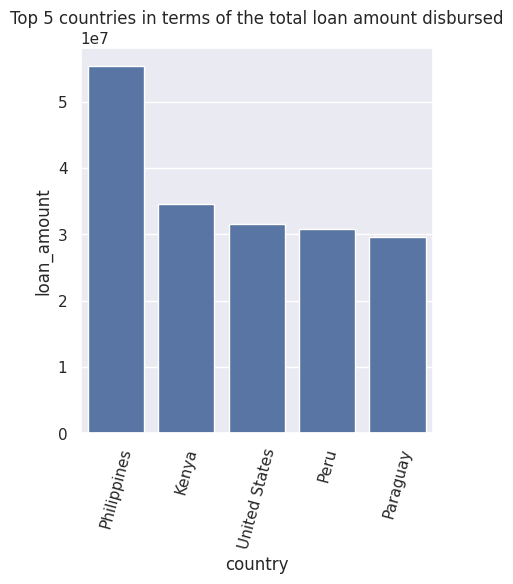

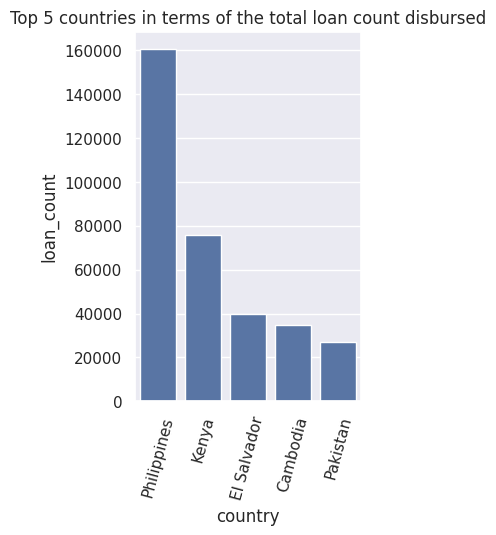

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(x='country',y='loan_amount',data=country_loan_amount)
plt.title('Top 5 countries in terms of the total loan amount disbursed')
plt.xlabel('country')
plt.ylabel('loan_amount')
plt.xticks(rotation=75)
plt.show()

plt.subplot(1,2,2)
sns.barplot(x='country',y='loan_count',data=countries_loan_count)
plt.title('Top 5 countries in terms of the total loan count disbursed')
plt.xlabel('country')
plt.ylabel('loan_count')
plt.xticks(rotation=75)
plt.show()


#How are loans distributed across different sectors?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [ ]:
uganda['sector'].value_counts()

,count
sector,
Food,4918
Agriculture,4619
Retail,3957
Education,1911
Clothing,1610
Housing,988
Services,988
Transportation,512
Personal Use,318


In [ ]:
loan_distribution_sector=uganda.groupby('sector')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head(5)
loan_distribution_sector.columns=['sector','loan_amount']
loan_distribution_sector

,sector,loan_amount
0,Agriculture,3609350.0
6,Food,3287375.0
11,Retail,3036625.0
4,Education,1889875.0
2,Clothing,942650.0


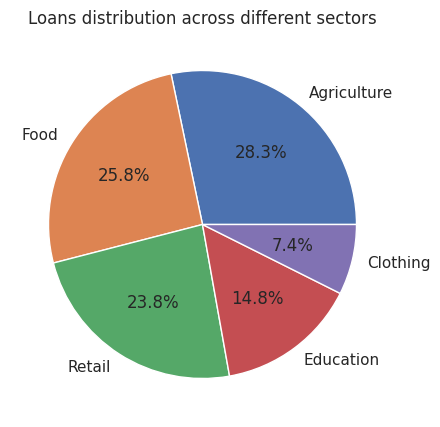

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(loan_distribution_sector['loan_amount'],labels=loan_distribution_sector['sector'],autopct='%1.1f%%')
plt.title('Loans distribution across different sectors')
plt.show()


#What are the top 5 activities for which loans are disbursed in Each sector?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [ ]:
uganda['activity'].value_counts()

,count
activity,
Farming,2487
General Store,1901
Education provider,1144
Personal Housing Expenses,781
Clothing Sales,682
...,...
Upholstery,1
Souvenir Sales,1
Cobbler,1


In [ ]:
top_5_activities=uganda.groupby(['sector','activity'])['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head()
top_5_activities.columns=['sector','activity','loan_amount']
top_5_activities

,sector,activity,loan_amount
6,Agriculture,Farming,1776150.0
31,Education,Education provider,1428300.0
81,Retail,General Store,1426125.0
61,Housing,Personal Housing Expenses,599125.0
3,Agriculture,Cattle,566900.0


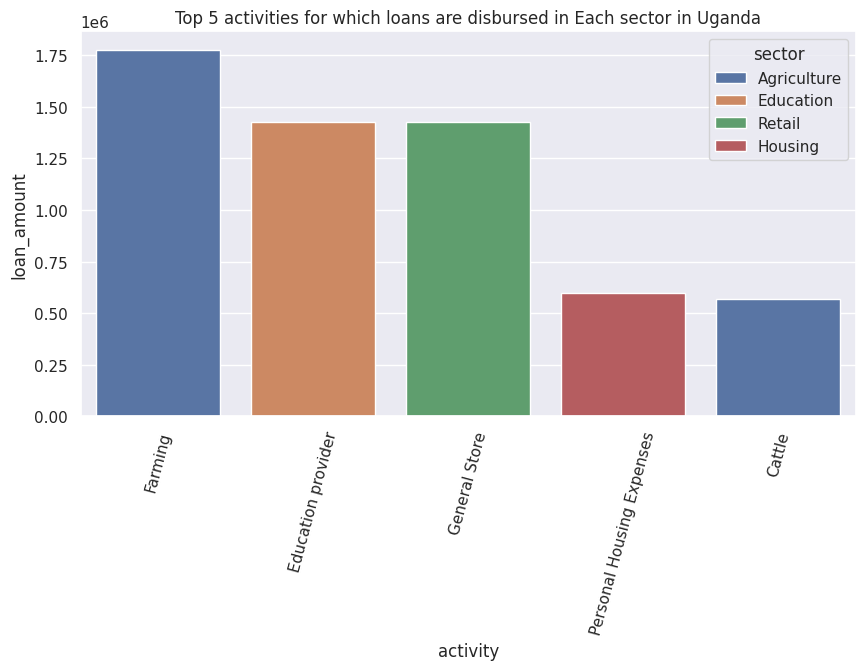

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='activity',y='loan_amount',hue='sector',data=top_5_activities)
plt.title('Top 5 activities for which loans are disbursed in Each sector in Uganda')
plt.xlabel('activity')
plt.ylabel('loan_amount')
plt.xticks(rotation=75)
plt.show()


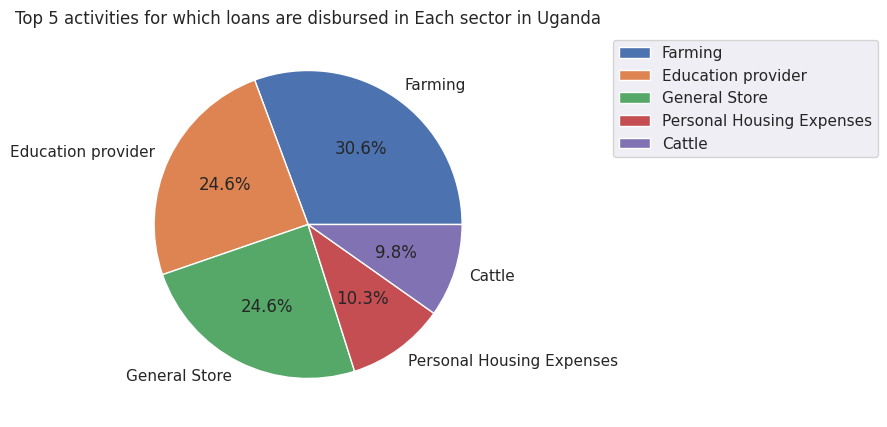

In [ ]:
#plotting pie
plt.figure(figsize=(10,5))
plt.pie(top_5_activities['loan_amount'],labels=top_5_activities['activity'],autopct='%1.1f%%')
plt.title('Top 5 activities for which loans are disbursed in Each sector in Uganda')
plt.legend(loc='upper right',bbox_to_anchor=(2,1))
plt.show()

#How many unique partners are involved in loan disbursement, and which partner is involved the most?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [ ]:
uganda['partner_id'].value_counts()

,count
partner_id,
163.0,10579
222.0,4082
65.0,2714
112.0,1530
329.0,1122
343.0,262
259.0,166
360.0,58
287.0,57


In [ ]:
uganda_2.columns

Index(['Partner ID', 'Field Partner Name', 'sector', 'Loan Theme ID',
       'Loan Theme Type', 'country', 'forkiva', 'region', 'geocode_old', 'ISO',
       'number', 'amount', 'LocationName', 'geocode', 'names', 'geo', 'lat',
       'lon', 'mpi_region', 'mpi_geo', 'rural_pct'],
      dtype='object')

In [ ]:
uganda['partner']=uganda_2['Field Partner Name']

In [ ]:
uganda.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date,partner
0,653954,100.0,100.0,Home Energy,Personal Use,to pay for a cooking gas package so that he ca...,UG,Uganda,Bulenga - Nankwandde,UGX,...,2014-01-05 22:16:53+00:00,2013-12-12 08:00:00+00:00,2014-01-08 00:29:31+00:00,9.0,4,n_a,male,irregular,2014-01-05,BRAC Uganda
1,653953,100.0,100.0,Home Energy,Personal Use,to pay for a package of clean energy so that h...,UG,Uganda,Namulanda - Off Entebbe Road,UGX,...,2014-01-05 21:53:00+00:00,2013-12-23 08:00:00+00:00,2014-01-07 16:41:34+00:00,7.0,1,n_a,male,irregular,2014-01-05,BRAC Uganda


In [ ]:
uganda['partner'].value_counts()

,count
partner,
UGAFODE Microfinance,103
BRAC Uganda,77
Impact Carbon,64
HOFOKAM,38
UpEnergy,9
Jibu,4
Micro Credit for Development and Transformation SACCO (MCDT SACCO),1
Youth Initiative for Community Empowerment,1
Yunus Social Business (YSB),1


In [ ]:
uganda['partner'].unique()

array(['BRAC Uganda',
       'Micro Credit for Development and Transformation SACCO (MCDT SACCO)',
       'HOFOKAM', 'UGAFODE Microfinance',
       'Youth Initiative for Community Empowerment', 'UpEnergy',
       'Yunus Social Business (YSB)', 'Impact Carbon',
       'The Alliance for Artisan Enterprise at The Aspen Institute',
       'N/A, direct to Mavuno Harvest', 'Jibu',
       'N/A, direct to Brent Oils', 'N/A, direct to Jakana Foods',
       'N/A, direct to All Across Africa', 'N/A direct to BioLite Inc.',
       nan], dtype=object)

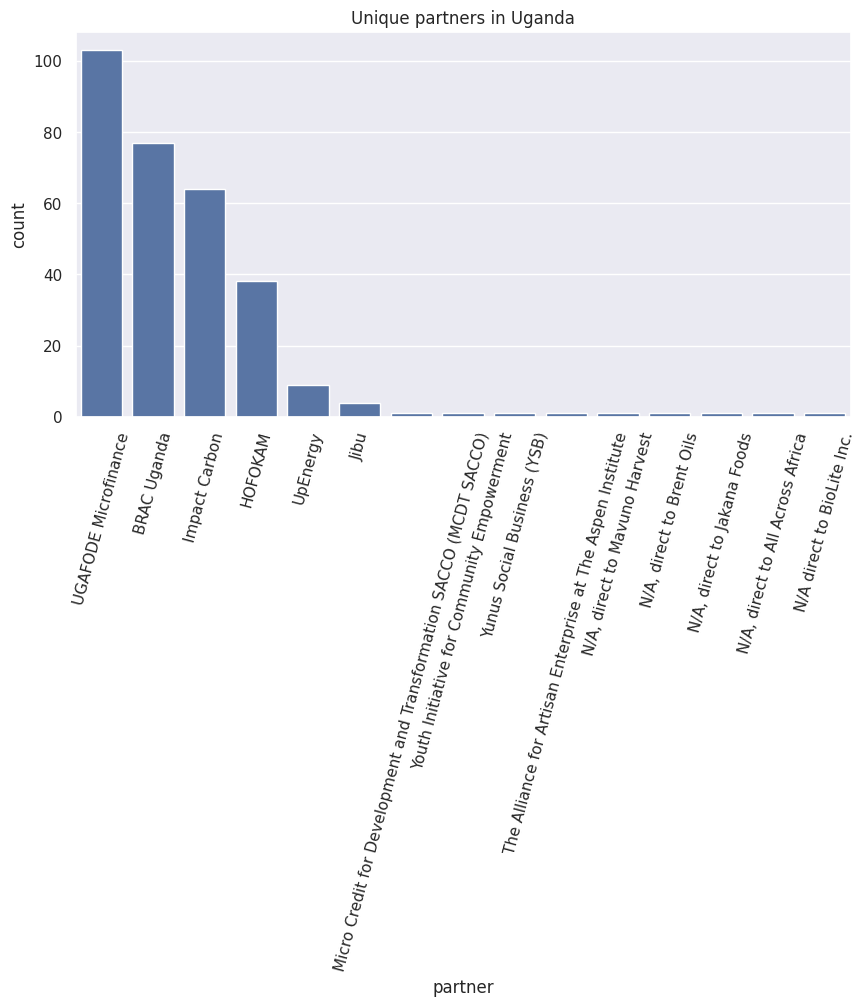

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=uganda['partner'].value_counts().index,y=uganda['partner'].value_counts())
plt.title('Unique partners in Uganda')
plt.xlabel('partner')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()



#What is the average repayment interval for the loans?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner'],
      dtype='object')

In [ ]:
uganda['repayment_interval'].value_counts()

,count
repayment_interval,
monthly,13211
irregular,7260
bullet,130


In [ ]:
avg_repayment_interval=uganda.groupby('repayment_interval')['loan_amount'].mean().reset_index().sort_values(by='loan_amount',ascending=False)
avg_repayment_interval.columns=['repayment_interval','loan_amount']
avg_repayment_interval

,repayment_interval,loan_amount
0,bullet,1835.000000
2,monthly,817.178866
1,irregular,599.869146


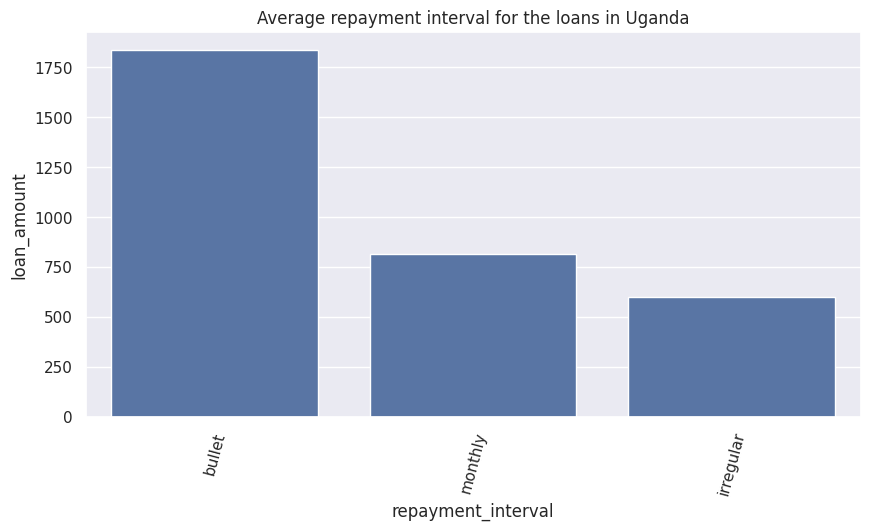

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='repayment_interval',y='loan_amount',data=avg_repayment_interval)
plt.title('Average repayment interval for the loans in Uganda')
plt.xlabel('repayment_interval')
plt.ylabel('loan_amount')
plt.xticks(rotation=75)
plt.show()

#How are borrower genders distributed across different loan activities?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner'],
      dtype='object')

In [ ]:
uganda['borrower_genders'].value_counts()

,count
borrower_genders,
male,10033
female,8215
n_a,211
"female, female",198
"female, female, female, female, female",109
...,...
"female, female, male, male, male, male, male, male, male, male, male, male, female, female, female, female, male, male, female, male, male, male, female, female, female",1
"female, male, female, male, male, male, female, male, female, male, male, male, male, female, female, female, male",1
"male, female, female, male, female, male, male, male, female",1


In [ ]:
def gender_distribution(gender):
  gender=str(gender)
  if gender.startswith('male'):
    return 'male'
  elif gender.startswith('female'):
    return 'female'
    return gender

In [ ]:
uganda['main_gender']=uganda['borrower_genders'].apply(gender_distribution)

In [ ]:
uganda.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date,partner,main_gender
0,653954,100.0,100.0,Home Energy,Personal Use,to pay for a cooking gas package so that he ca...,UG,Uganda,Bulenga - Nankwandde,UGX,...,2013-12-12 08:00:00+00:00,2014-01-08 00:29:31+00:00,9.0,4,n_a,male,irregular,2014-01-05,BRAC Uganda,male
1,653953,100.0,100.0,Home Energy,Personal Use,to pay for a package of clean energy so that h...,UG,Uganda,Namulanda - Off Entebbe Road,UGX,...,2013-12-23 08:00:00+00:00,2014-01-07 16:41:34+00:00,7.0,1,n_a,male,irregular,2014-01-05,BRAC Uganda,male


In [ ]:
uganda['main_gender'].value_counts()

,count
main_gender,
male,10866
female,9524


In [ ]:
gender_distribution=uganda.groupby('sector')['main_gender'].value_counts().reset_index()
gender_distribution

,sector,main_gender,count
0,Agriculture,male,3175
1,Agriculture,female,1367
2,Arts,female,42
3,Arts,male,17
4,Clothing,female,1241
5,Clothing,male,365
6,Construction,male,171
7,Construction,female,89
8,Education,male,1253
9,Education,female,641


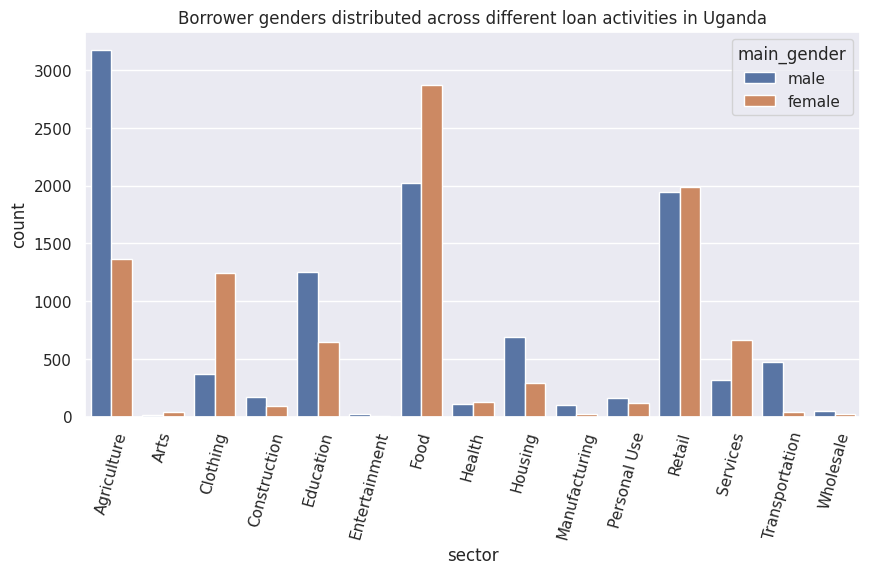

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='sector',y='count',hue='main_gender',data=gender_distribution)
plt.title('Borrower genders distributed across different loan activities in Uganda')
plt.xlabel('sector')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#How many loans were disbursed each year?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender'],
      dtype='object')

In [ ]:
uganda['disbursed_time'].value_counts()

,count
disbursed_time,
2014-06-13 07:00:00+00:00,111
2014-06-20 07:00:00+00:00,93
2015-06-12 07:00:00+00:00,84
2014-07-16 07:00:00+00:00,81
2014-07-11 07:00:00+00:00,80
...,...
2016-03-26 07:00:00+00:00,1
2016-05-22 07:00:00+00:00,1
2016-05-08 07:00:00+00:00,1


In [ ]:
uganda['disbursed_time']=pd.to_datetime(uganda['disbursed_time'])

In [ ]:
uganda['year']=uganda['disbursed_time'].dt.year

In [ ]:
uganda['year'].value_counts().reset_index()

,year,count
0,2014,7390
1,2015,6152
2,2016,4538
3,2017,2480
4,2013,41


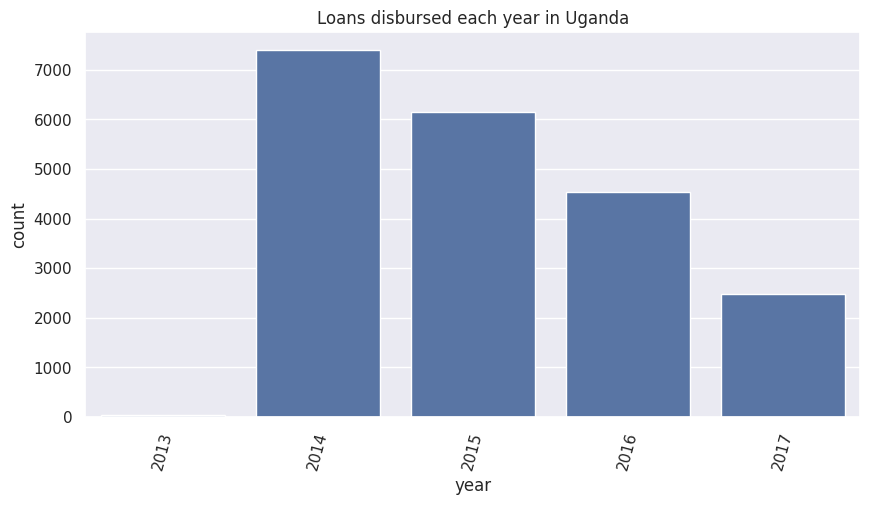

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=uganda['year'].value_counts().index,y=uganda['year'].value_counts())
plt.title('Loans disbursed each year in Uganda')
plt.xlabel('year')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

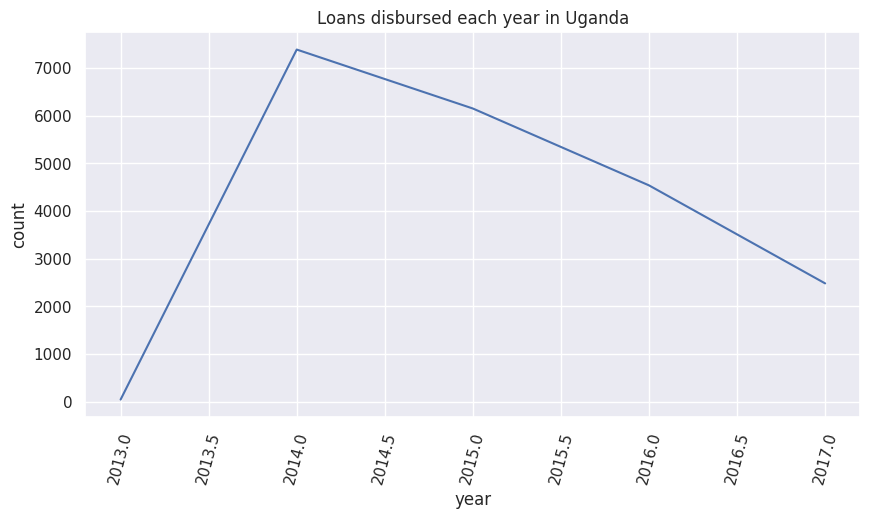

In [ ]:
#lineplot
plt.figure(figsize=(10,5))
sns.lineplot(x=uganda['year'].value_counts().index,y=uganda['year'].value_counts())
plt.title('Loans disbursed each year in Uganda')
plt.xlabel('year')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#How is the trend of funding amount changing over the years?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year'],
      dtype='object')

In [ ]:
uganda['funded_amount'].value_counts()

,count
funded_amount,
300.0,1126
600.0,815
150.0,750
200.0,718
175.0,671
...,...
4100.0,1
6525.0,1
5450.0,1


In [ ]:
uganda.groupby('year')['funded_amount'].sum().reset_index()

,year,funded_amount
0,2013,18250.0
1,2014,5351275.0
2,2015,4286100.0
3,2016,3098575.0
4,2017,1388475.0


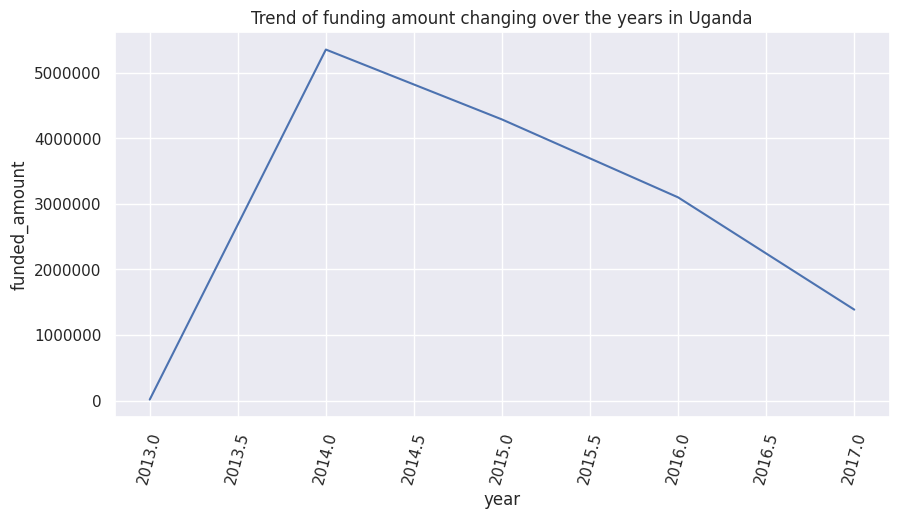

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=uganda.groupby('year')['funded_amount'].sum().index,y=uganda.groupby('year')['funded_amount'].sum())
plt.title('Trend of funding amount changing over the years in Uganda')
plt.ticklabel_format(style='plain',axis='y')
plt.xlabel('year')
plt.ylabel('funded_amount')
plt.xticks(rotation=75)
plt.show()

#What is the average term in months for loans, and how does this vary across different sectors?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year'],
      dtype='object')

In [ ]:
uganda['term_in_months'].value_counts()

,count
term_in_months,
8.0,4285
14.0,4171
12.0,2272
10.0,2259
6.0,1505
7.0,1204
11.0,1117
9.0,879
13.0,538


In [ ]:
#average term in months and how it is spread across different sectors
avg_term_in_months=uganda.groupby('sector')['term_in_months'].mean().reset_index().round(2).sort_values(by='term_in_months',ascending=False)
avg_term_in_months.columns=['sector','term_in_months']
avg_term_in_months

,sector,term_in_months
4,Education,18.48
8,Housing,13.20
3,Construction,12.33
0,Agriculture,12.16
14,Wholesale,11.81
7,Health,11.49
13,Transportation,11.39
9,Manufacturing,10.85
11,Retail,10.76
12,Services,10.52


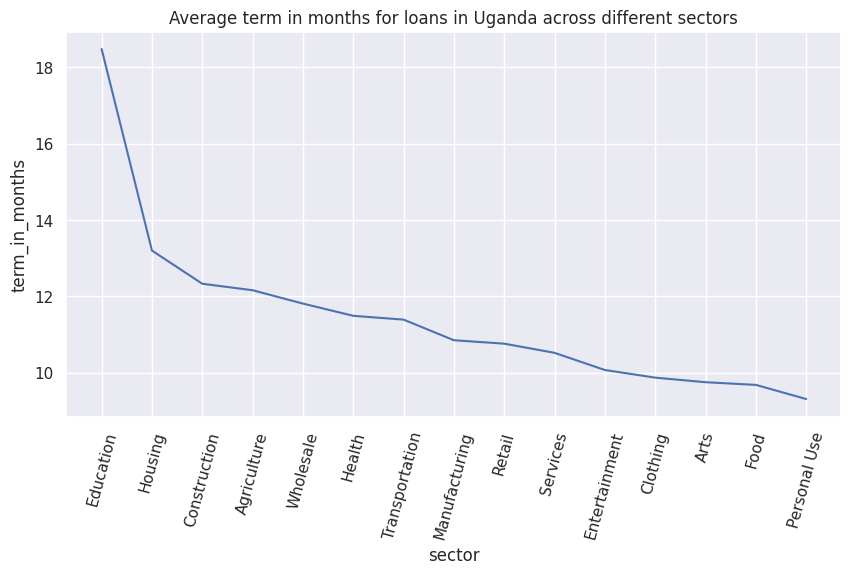

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='sector',y='term_in_months',data=avg_term_in_months)
plt.title('Average term in months for loans in Uganda across different sectors')
plt.xlabel('sector')
plt.ylabel('term_in_months')
plt.xticks(rotation=75)
plt.show()

#How long on average does it take for a loan to be funded after being posted on Kiva?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year'],
      dtype='object')

In [ ]:
uganda['posted_time'].value_counts()

,count
posted_time,
2014-12-08 06:49:23+00:00,2
2015-12-10 13:52:29+00:00,2
2015-01-19 13:47:09+00:00,2
2016-03-21 13:43:39+00:00,2
2016-01-25 07:39:35+00:00,1
...,...
2014-12-04 08:43:31+00:00,1
2014-12-04 13:19:23+00:00,1
2014-12-04 12:35:52+00:00,1


In [ ]:
import datetime

In [ ]:
uganda['posted_time']=pd.to_datetime(uganda['posted_time'])

In [ ]:
uganda['funded_time'] = uganda['funded_time'].replace('n_a', pd.NaT)
uganda['funded_time'] = pd.to_datetime(uganda['funded_time'], format='%Y-%m-%d %H:%M:%S%z', errors='coerce')

In [ ]:
uganda['funded_time'].value_counts()

,count
funded_time,
2016-07-18 17:50:14+00:00,8
2016-03-28 17:40:27+00:00,7
2014-11-06 19:51:39+00:00,6
2014-10-01 07:11:29+00:00,5
2016-07-03 01:59:49+00:00,5
...,...
2014-12-10 20:39:10+00:00,1
2014-12-10 02:57:01+00:00,1
2014-12-12 15:31:58+00:00,1


In [ ]:
uganda['time_to_fund'] = uganda['funded_time'] - uganda['posted_time']

In [ ]:
uganda['time_to_fund'].value_counts().mean()

1.0042925540696714

#How do the loan amounts differ by region within countries?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund'],
      dtype='object')

In [ ]:
loan_distribution_by_region_countries=kiva.groupby(['country','region'])['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head(5)
loan_distribution_by_region_countries

,country,region,loan_amount
11725,The Democratic Republic of the Congo,"Goma, North Kivu province",7397975.0
783,Bolivia,La Paz / El Alto,6838300.0
7095,Peru,Cusco,6222075.0
11689,Tanzania,Dar es Salaam,5113875.0
6830,Pakistan,Lahore,3984575.0


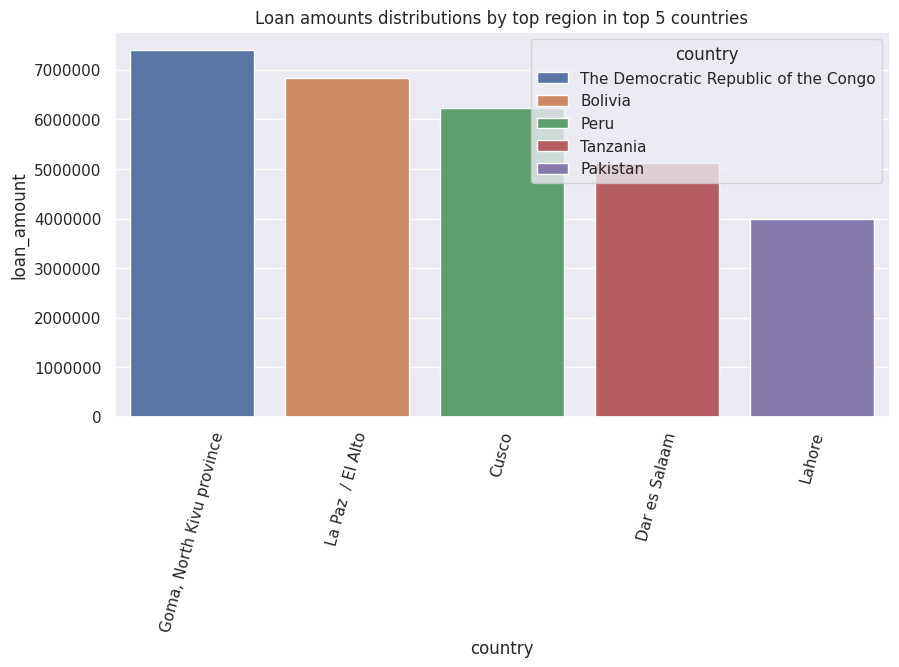

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='loan_amount',hue='country',data=loan_distribution_by_region_countries)
plt.title('Loan amounts distributions by top region in top 5 countries')
plt.xlabel('country')
plt.ticklabel_format(style='plain',axis='y')
plt.ylabel('loan_amount')
plt.xticks(rotation=75)
plt.show()

#Does the currency in which the loan was disbursed influence the number of lenders?

In [ ]:
uganda['currency'].value_counts()

,count
currency,
UGX,20534
USD,67


In [ ]:
uganda_lendercount_currency=uganda.groupby('currency')['lender_count'].sum().reset_index().sort_values(by='lender_count',ascending=False)
uganda_lendercount_currency

,currency,lender_count
0,UGX,391678
1,USD,8974


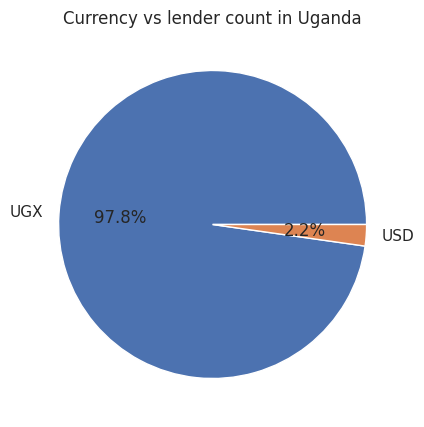

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(uganda_lendercount_currency['lender_count'],labels=uganda_lendercount_currency['currency'],autopct='%1.1f%%')
plt.title('Currency vs lender count in Uganda')
plt.show()

#How does the number of lenders vary across different sectors and activities?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund'],
      dtype='object')

In [ ]:
uganda['lender_count'].value_counts()

,count
lender_count,
8,969
7,962
6,950
9,888
5,885
...,...
131,1
220,1
108,1


In [ ]:
uganda_sector_activity_lendercount=uganda.groupby(['sector','activity'])['lender_count'].sum().reset_index().sort_values(by='lender_count',ascending=False).head(5)
uganda_sector_activity_lendercount

,sector,activity,lender_count
6,Agriculture,Farming,47712
31,Education,Education provider,43905
81,Retail,General Store,33070
61,Housing,Personal Housing Expenses,14592
47,Food,Food Production/Sales,13648


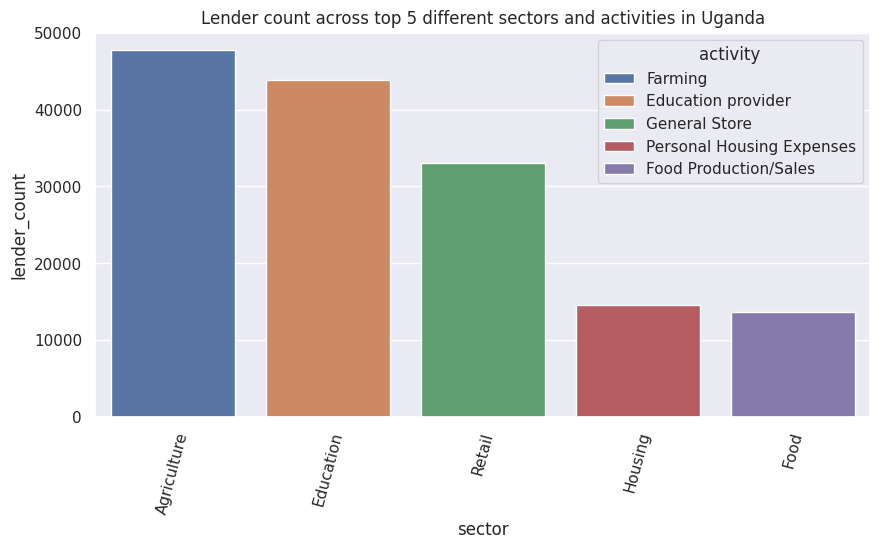

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='sector',y='lender_count',hue='activity',data=uganda_sector_activity_lendercount)
plt.title('Lender count across top 5 different sectors and activities in Uganda')
plt.xlabel('sector')
plt.ylabel('lender_count')
plt.xticks(rotation=75)
plt.show()

#Are there specific periods in the year when the loan disbursement is more?

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund'],
      dtype='object')

In [ ]:
uganda['disbursed_time'].value_counts()

,count
disbursed_time,
2014-06-13 07:00:00+00:00,111
2014-06-20 07:00:00+00:00,93
2015-06-12 07:00:00+00:00,84
2014-07-16 07:00:00+00:00,81
2014-07-11 07:00:00+00:00,80
...,...
2016-03-26 07:00:00+00:00,1
2016-05-22 07:00:00+00:00,1
2016-05-08 07:00:00+00:00,1


In [ ]:
uganda['disbursed_time']=pd.to_datetime(uganda['disbursed_time'])

In [ ]:
uganda['month']=uganda['disbursed_time'].dt.month

In [ ]:
monthly_loan_disbursement=uganda['month'].value_counts()
monthly_loan_disbursement

,count
month,
6,2279
5,2111
3,2085
4,2042
2,1839
1,1806
7,1725
8,1465
10,1424


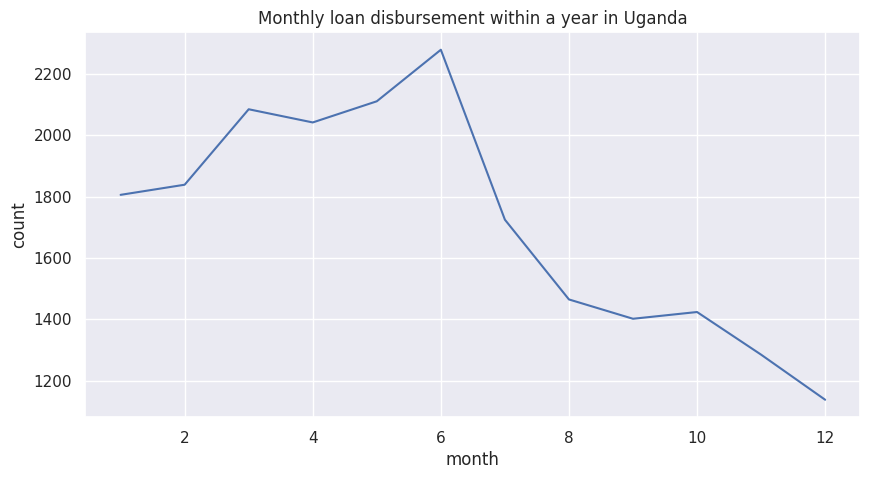

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_loan_disbursement.index,y=monthly_loan_disbursement)
plt.title('Monthly loan disbursement within a year in Uganda')
plt.xlabel('month')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

#Display the top 10 loan activities in the dataset

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund', 'month'],
      dtype='object')

In [ ]:
uganda['activity'].value_counts().head(10)

,count
activity,
Farming,2487
General Store,1901
Education provider,1144
Personal Housing Expenses,781
Clothing Sales,682
Retail,671
Food Production/Sales,660
Used Clothing,656
Primary/secondary school costs,649


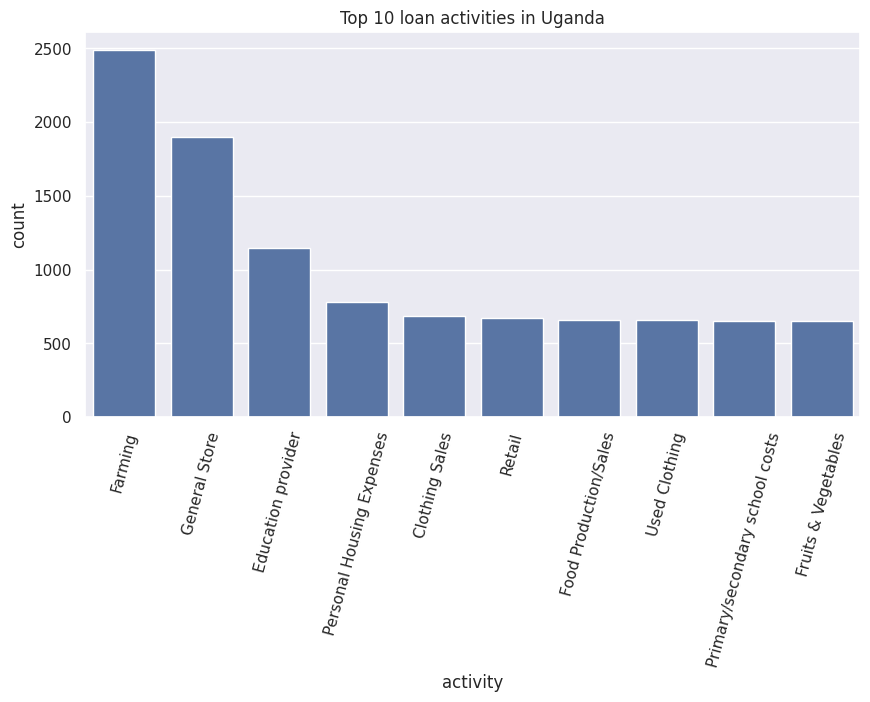

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=uganda['activity'].value_counts().head(10).index,y=uganda['activity'].value_counts().head(10))
plt.title('Top 10 loan activities in Uganda')
plt.xlabel('activity')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#Identify the most prominent field partners

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund', 'month'],
      dtype='object')

In [ ]:
uganda['partner'].value_counts()

,count
partner,
UGAFODE Microfinance,103
BRAC Uganda,77
Impact Carbon,64
HOFOKAM,38
UpEnergy,9
Jibu,4
Micro Credit for Development and Transformation SACCO (MCDT SACCO),1
Youth Initiative for Community Empowerment,1
Yunus Social Business (YSB),1


In [ ]:
uganda['partner'].value_counts().head(10)

,count
partner,
UGAFODE Microfinance,103
BRAC Uganda,77
Impact Carbon,64
HOFOKAM,38
UpEnergy,9
Jibu,4
Micro Credit for Development and Transformation SACCO (MCDT SACCO),1
Youth Initiative for Community Empowerment,1
Yunus Social Business (YSB),1


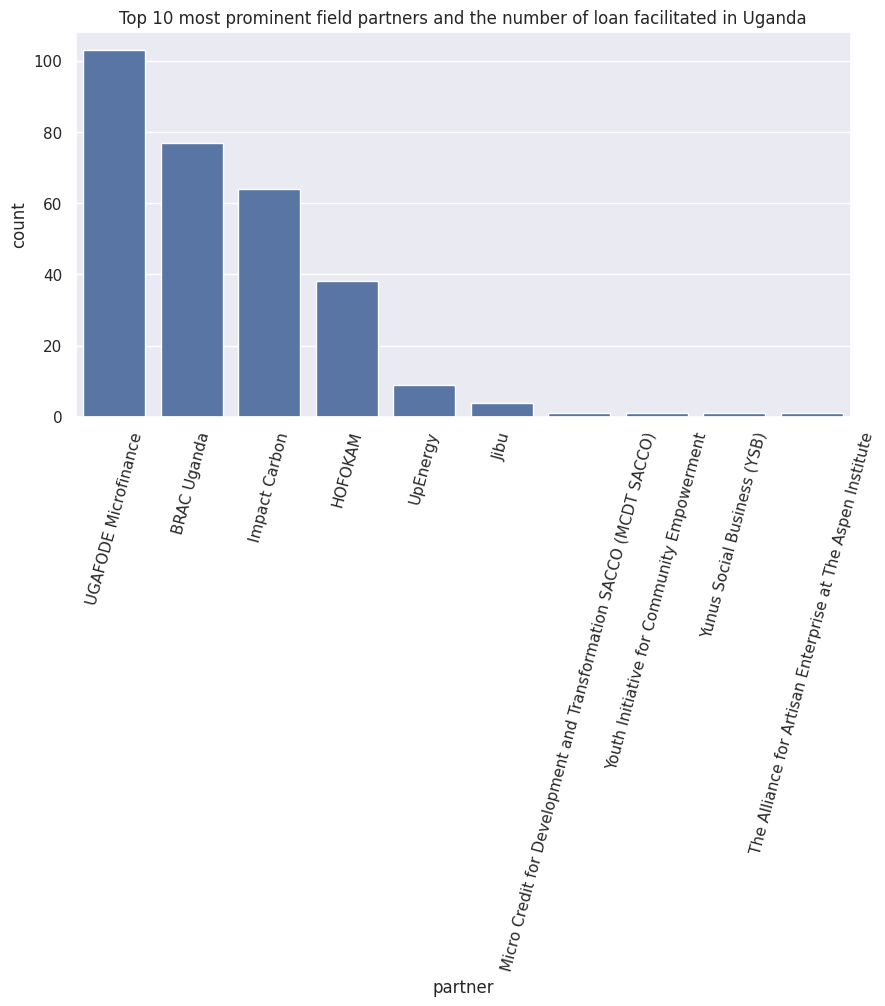

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=uganda['partner'].value_counts().head(10).index,y=uganda['partner'].value_counts().head(10))
plt.title('Top 10 most prominent field partners and the number of loan facilitated in Uganda')
plt.xlabel('partner')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#Present the names of field partners from loan_themes_by_region.csv along with their total loan amounts from kiva_loans.csv.

In [ ]:
uganda['partner'].value_counts()

,count
partner,
UGAFODE Microfinance,103
BRAC Uganda,77
Impact Carbon,64
HOFOKAM,38
UpEnergy,9
Jibu,4
Micro Credit for Development and Transformation SACCO (MCDT SACCO),1
Youth Initiative for Community Empowerment,1
Yunus Social Business (YSB),1


In [ ]:
loan_amount_by_partners=uganda.groupby('partner')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False)
loan_amount_by_partners


,partner,loan_amount
11,UGAFODE Microfinance,60875.0
2,Impact Carbon,40575.0
0,BRAC Uganda,39775.0
1,HOFOKAM,25375.0
12,UpEnergy,7750.0
3,Jibu,3500.0
8,"N/A, direct to Jakana Foods",1225.0
4,Micro Credit for Development and Transformatio...,1200.0
7,"N/A, direct to Brent Oils",500.0
13,Youth Initiative for Community Empowerment,425.0


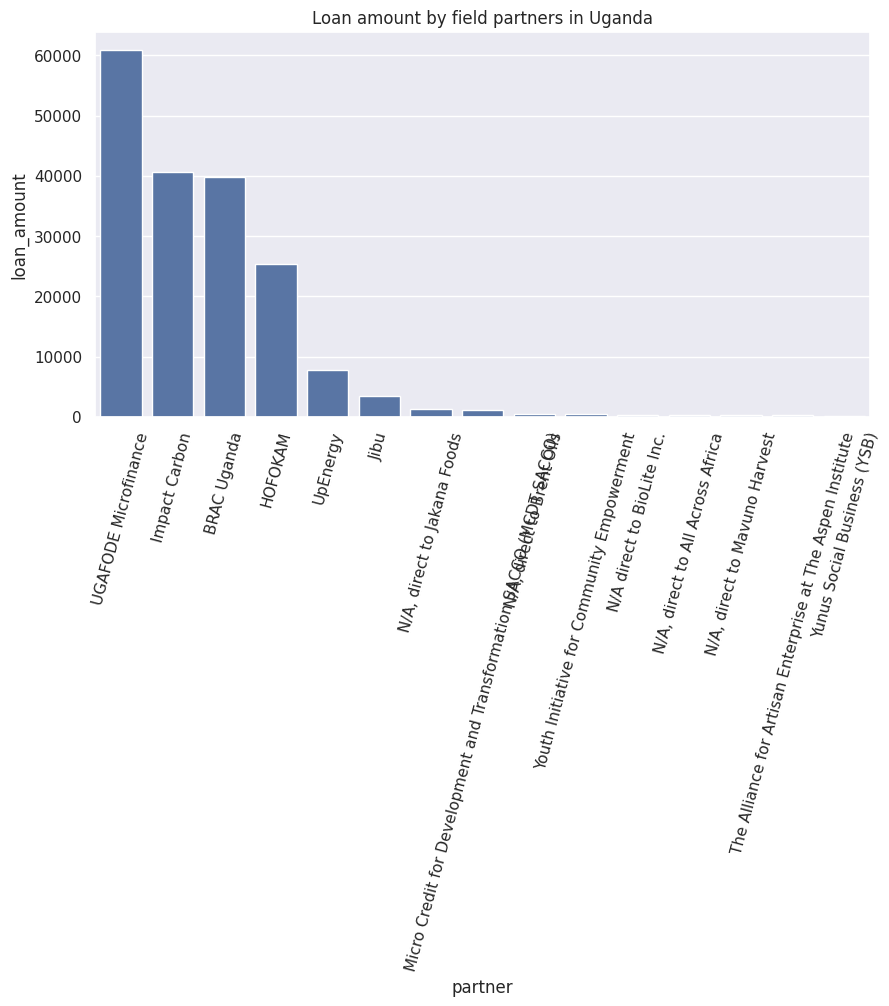

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='partner',y='loan_amount',data=loan_amount_by_partners)
plt.title('Loan amount by field partners in Uganda')
plt.xlabel('partner')
plt.ylabel('loan_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Determine the primary reasons for granting loans

In [ ]:
uganda['use'].value_counts().head(10)

,count
use,
to purchase a water filtration system to provide clean drinking water for its students.,419
To purchase a water filtration system to provide clean drinking water for its students.,225
n_a,211
To purchase a water filtration system to provide clean drinking water for its students.,190
to pay school fees for his children.,171
to pay school fees for her children.,130
to buy more clothes to sell.,99
to buy cocoa to sell.,85
to buy more maize to sell.,73


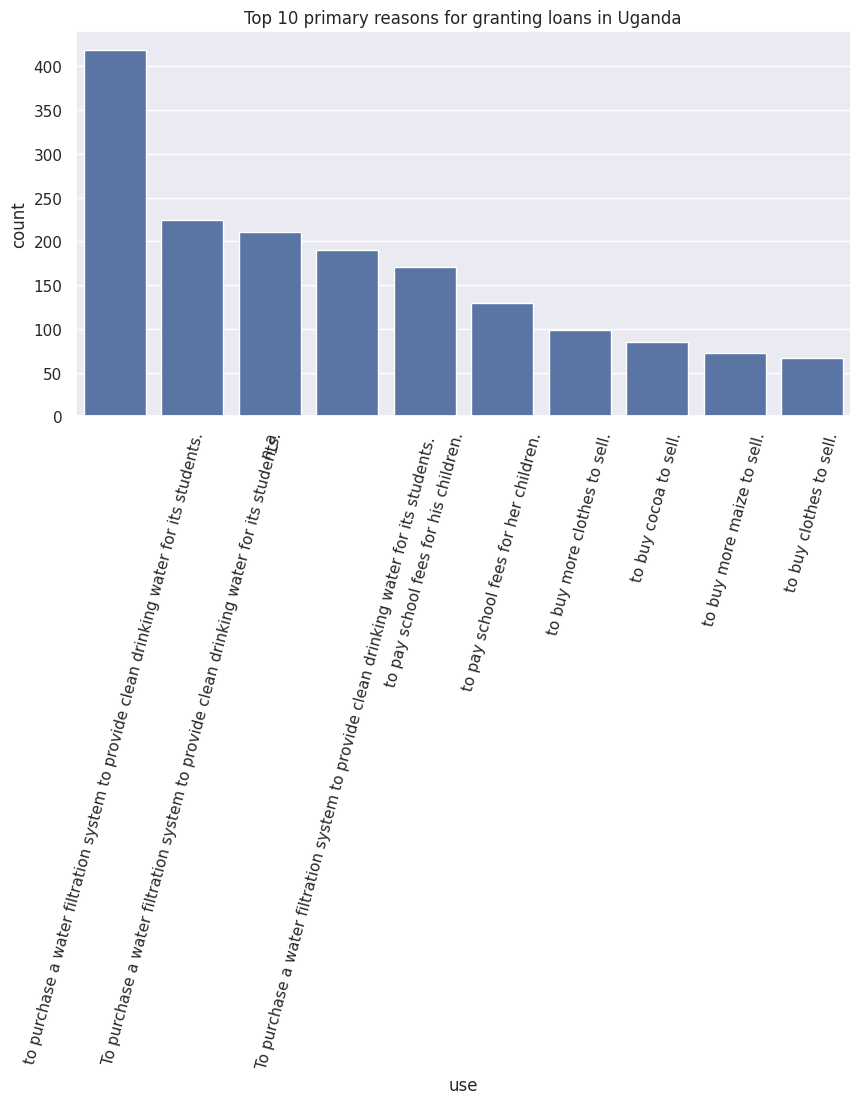

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=uganda['use'].value_counts().head(10).index,y=uganda['use'].value_counts().head(10))
plt.title('Top 10 primary reasons for granting loans in Uganda')
plt.xlabel('use')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#Visualize the top regions ranked by loan amount

In [ ]:
uganda['region'].value_counts()

,count
region,
Kampala,2149
Kasese,1989
Fort Portal,1944
Kamwenge,1724
Hoima,1360
...,...
Namuseere,1
Kyebando,1
NateteB,1


In [ ]:
top_regions_by_loan_amount=uganda.groupby('region')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head(10)
top_regions_by_loan_amount

,region,loan_amount
68,Kasese,1405750.0
35,Fort Portal,1385025.0
61,Kampala,1323550.0
63,Kamwenge,1199975.0
53,Kagadi,1050650.0
39,Hoima,904225.0
21,Bundibugyo,750325.0
102,Kyenjojo,706700.0
119,Masindi,669275.0
43,Ishaka,481300.0


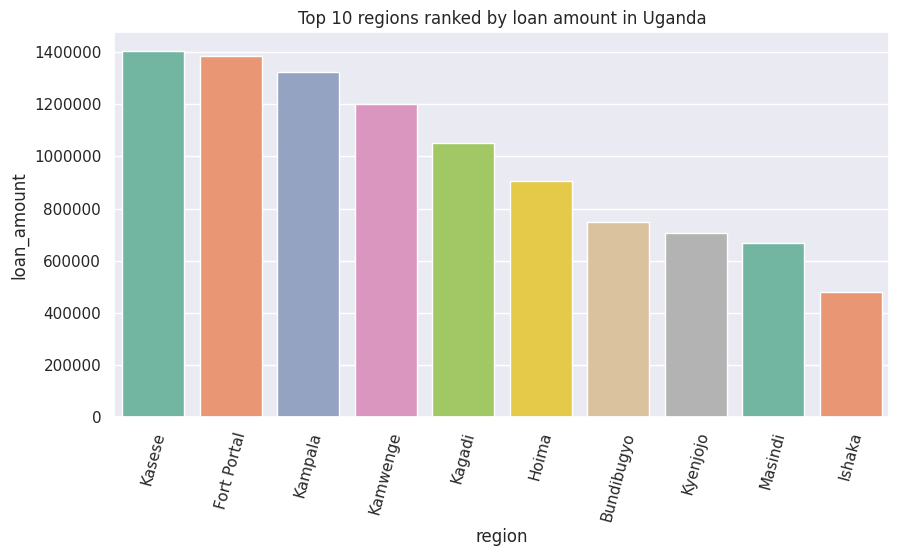

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='loan_amount',data=top_regions_by_loan_amount,palette='Set2')
plt.title('Top 10 regions ranked by loan amount in Uganda')
plt.xlabel('region')
plt.ylabel('loan_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Create a heatmap to explore correlations among numerical values.

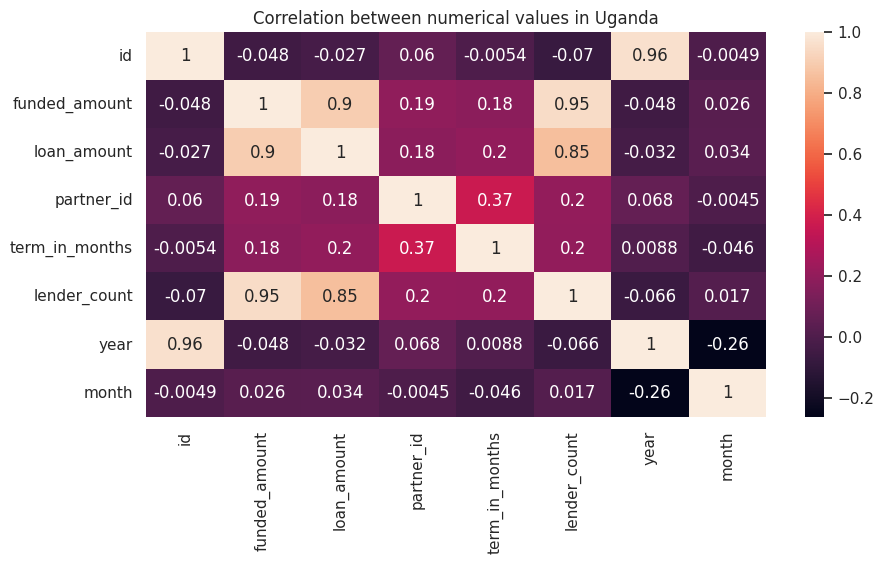

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(uganda.corr(numeric_only=True),annot=True)
plt.title('Correlation between numerical values in Uganda')
plt.show()

#Illustrate the distribution of loan amounts.


In [ ]:
uganda['loan_amount'].max()

50000.0

In [ ]:
uganda['loan_amount'].value_counts().sort_values(ascending=False)

,count
loan_amount,
300.0,1075
600.0,888
150.0,699
200.0,657
575.0,647
...,...
5400.0,1
4775.0,1
4825.0,1


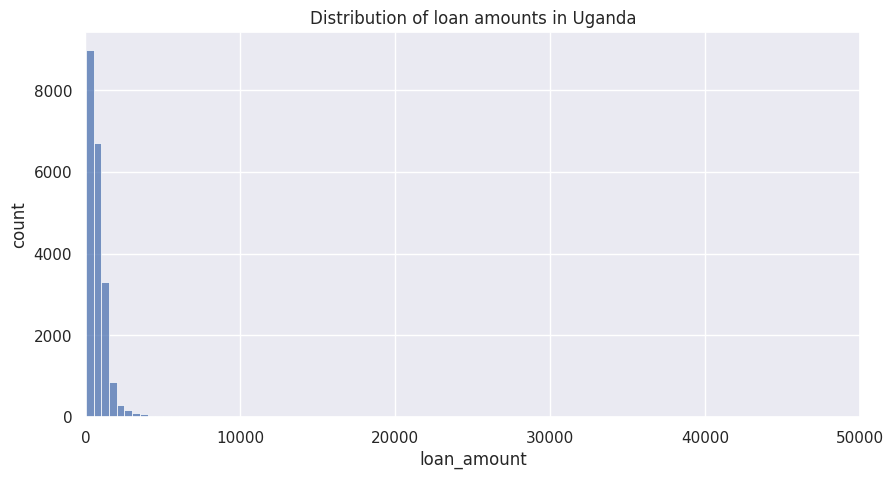

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(uganda['loan_amount'],bins=100)
plt.title('Distribution of loan amounts in Uganda')
plt.xlabel('loan_amount')
plt.ylabel('count')
plt.xlim(0,50000)
plt.show()
# Setting the axis range
#plt.xlim(0, 5)  # X-axis range from 0 to 5
#plt.ylim(0, 20) # Y-axis range from 0 to 20


#Illustrate the distribution of funded amounts.

In [ ]:
uganda['funded_amount'].value_counts()

,count
funded_amount,
300.0,1126
600.0,815
150.0,750
200.0,718
175.0,671
...,...
4100.0,1
6525.0,1
5450.0,1


In [ ]:
uganda['funded_amount'].max()

50000.0

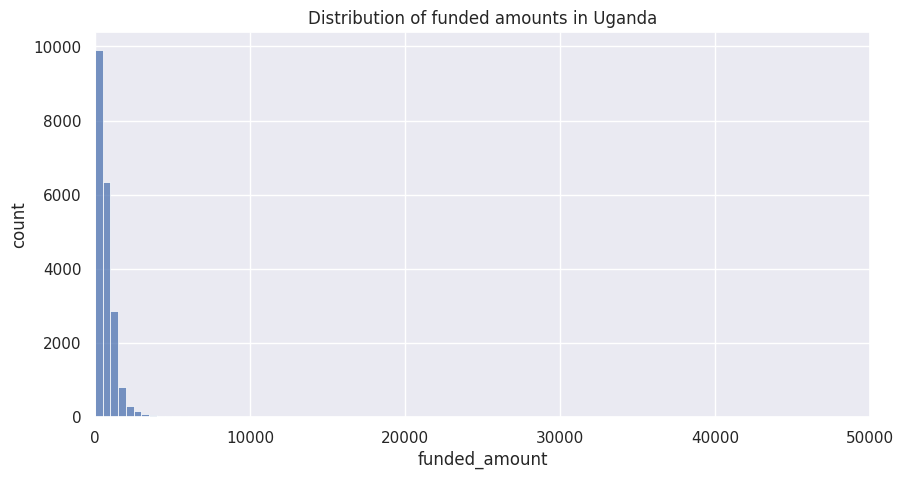

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(uganda['funded_amount'],bins=100)
plt.title('Distribution of funded amounts in Uganda')
plt.xlabel('funded_amount')
plt.ylabel('count')
plt.xlim(0,50000)
plt.show()
#

#Depict the distribution of repayment terms.

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund', 'month'],
      dtype='object')

In [ ]:
uganda['term_in_months'].value_counts()

,count
term_in_months,
8.0,4285
14.0,4171
12.0,2272
10.0,2259
6.0,1505
7.0,1204
11.0,1117
9.0,879
13.0,538


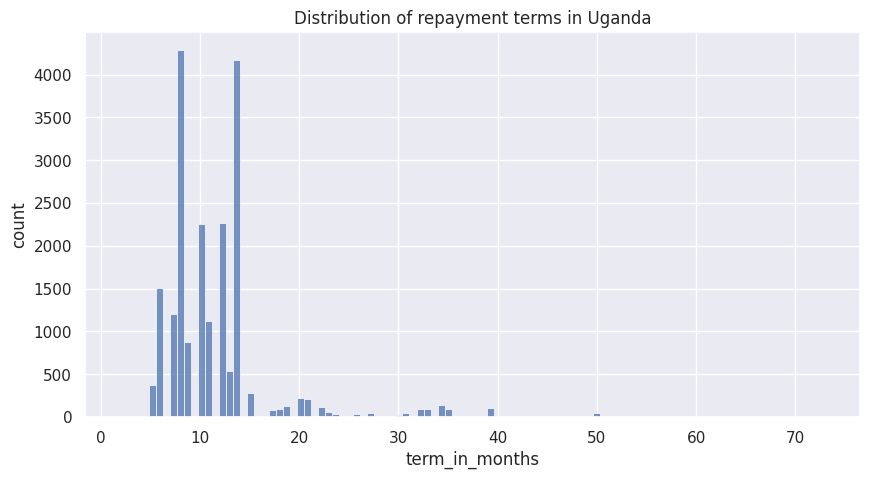

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(uganda['term_in_months'],bins=100)
plt.title('Distribution of repayment terms in Uganda')
plt.xlabel('term_in_months')
plt.ylabel('count')
plt.show()
#

#Explore the relationship between lender counts and funded amounts, providing explanations for the results.

In [ ]:
uganda['lender_count'].value_counts()

,count
lender_count,
8,969
7,962
6,950
9,888
5,885
...,...
131,1
220,1
108,1


In [ ]:
uganda['funded_amount'].value_counts()

,count
funded_amount,
300.0,1126
600.0,815
150.0,750
200.0,718
175.0,671
...,...
4100.0,1
6525.0,1
5450.0,1


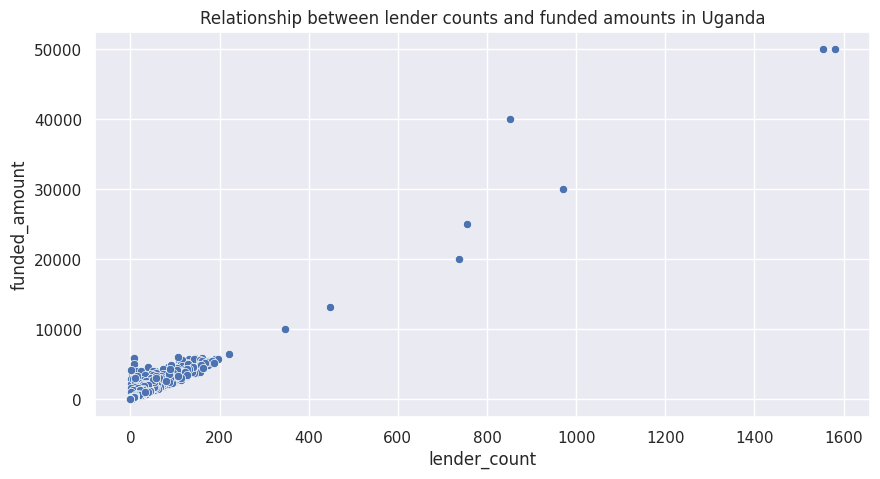

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='lender_count',y='funded_amount',data=uganda)
plt.title('Relationship between lender counts and funded amounts in Uganda')
plt.xlabel('lender_count')
plt.ylabel('funded_amount')
plt.show()

#Showcase the funded amount distribution by region.

In [ ]:
uganda['region'].value_counts()

,count
region,
Kampala,2149
Kasese,1989
Fort Portal,1944
Kamwenge,1724
Hoima,1360
...,...
Namuseere,1
Kyebando,1
NateteB,1


In [ ]:
founded_amount_dist_region=uganda.groupby('region')['funded_amount'].sum().reset_index().sort_values(by='funded_amount',ascending=False).head(10)
founded_amount_dist_region.columns=['region','funded_amount']
founded_amount_dist_region

,region,funded_amount
35,Fort Portal,1307975.0
68,Kasese,1298700.0
61,Kampala,1246675.0
63,Kamwenge,1078175.0
53,Kagadi,979625.0
39,Hoima,809350.0
21,Bundibugyo,705725.0
102,Kyenjojo,662700.0
119,Masindi,616650.0
43,Ishaka,448900.0


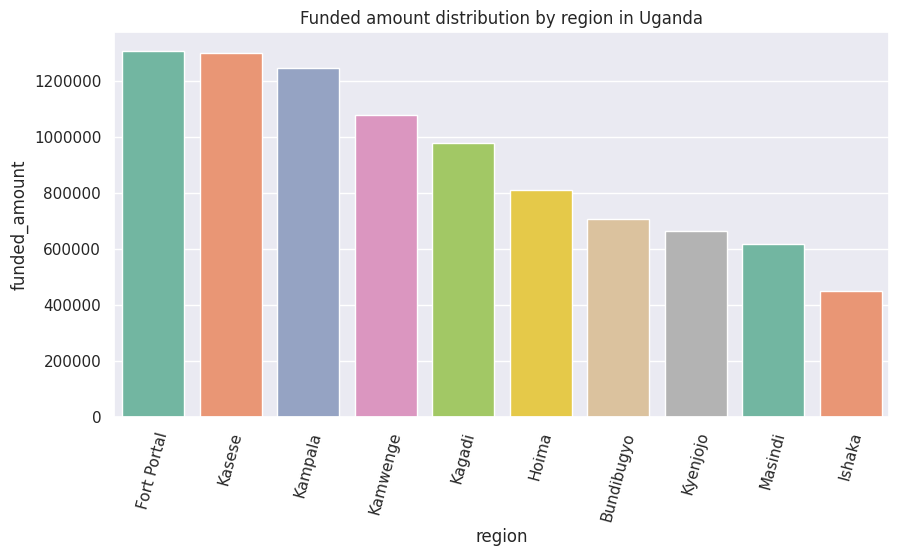

In [ ]:
from typing import Any
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='funded_amount',data=founded_amount_dist_region,palette='Set2')
plt.title('Funded amount distribution by region in Uganda')
plt.xlabel('region')
plt.ylabel('funded_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Visualize funded amounts with sector as a distinguishing factor.

In [ ]:
uganda['sector'].value_counts()

,count
sector,
Food,4918
Agriculture,4619
Retail,3957
Education,1911
Clothing,1610
Housing,988
Services,988
Transportation,512
Personal Use,318


In [ ]:
founded_amount_per_sector=uganda.groupby('sector')['funded_amount'].sum().reset_index().sort_values(by='funded_amount',ascending=False)
founded_amount_per_sector.columns=['sector','funded_amount']
founded_amount_per_sector

,sector,funded_amount
0,Agriculture,3376800.0
6,Food,3034075.0
11,Retail,2655900.0
4,Education,1877625.0
2,Clothing,864325.0
8,Housing,661650.0
12,Services,619875.0
13,Transportation,296675.0
3,Construction,212425.0
7,Health,206525.0


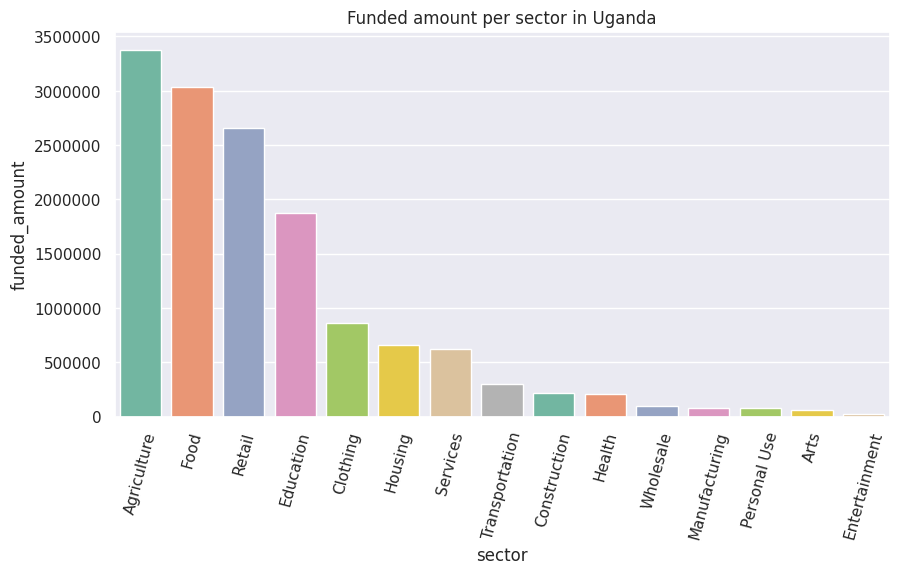

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='sector',y='funded_amount',data=founded_amount_per_sector,palette='Set2')
plt.title('Funded amount per sector in Uganda')
plt.xlabel('sector')
plt.ylabel('funded_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Present a boxplot analysis of regions against funded amounts.

In [ ]:
uganda['region'].value_counts()

,count
region,
Kampala,2149
Kasese,1989
Fort Portal,1944
Kamwenge,1724
Hoima,1360
...,...
Namuseere,1
Kyebando,1
NateteB,1


In [ ]:
region_founded_amount=uganda.groupby('region')['funded_amount'].sum().reset_index().sort_values(by='funded_amount',ascending=False).head(10)
region_founded_amount.columns=['region','funded_amount']
region_founded_amount

,region,funded_amount
35,Fort Portal,1307975.0
68,Kasese,1298700.0
61,Kampala,1246675.0
63,Kamwenge,1078175.0
53,Kagadi,979625.0
39,Hoima,809350.0
21,Bundibugyo,705725.0
102,Kyenjojo,662700.0
119,Masindi,616650.0
43,Ishaka,448900.0


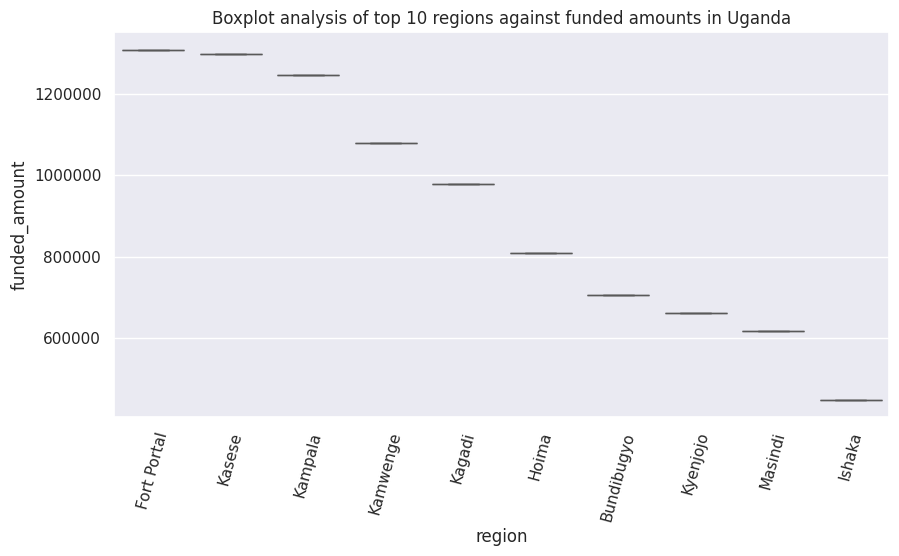

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='region',y='funded_amount',data=region_founded_amount,palette='Set2')
plt.title('Boxplot analysis of top 10 regions against funded amounts in Uganda')
plt.xlabel('region')
plt.ylabel('funded_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Examine repayment intervals across different regions.

In [ ]:
uganda['region'].value_counts()

,count
region,
Kampala,2149
Kasese,1989
Fort Portal,1944
Kamwenge,1724
Hoima,1360
...,...
Namuseere,1
Kyebando,1
NateteB,1


In [ ]:
uganda['repayment_interval'].value_counts()

,count
repayment_interval,
monthly,13211
irregular,7260
bullet,130


In [ ]:
top10_repayment_interval_per_region=uganda.groupby('region')['repayment_interval'].value_counts().reset_index().sort_values(by='count',ascending=False).head(10)
top10_repayment_interval_per_region

,region,repayment_interval,count
90,Kampala,irregular,1776
104,Kasese,monthly,1658
95,Kamwenge,monthly,1450
47,Fort Portal,monthly,1367
54,Hoima,monthly,1008
77,Kagadi,monthly,843
27,Bundibugyo,irregular,736
183,Masindi,monthly,629
28,Bundibugyo,monthly,608
154,Kyenjojo,monthly,596


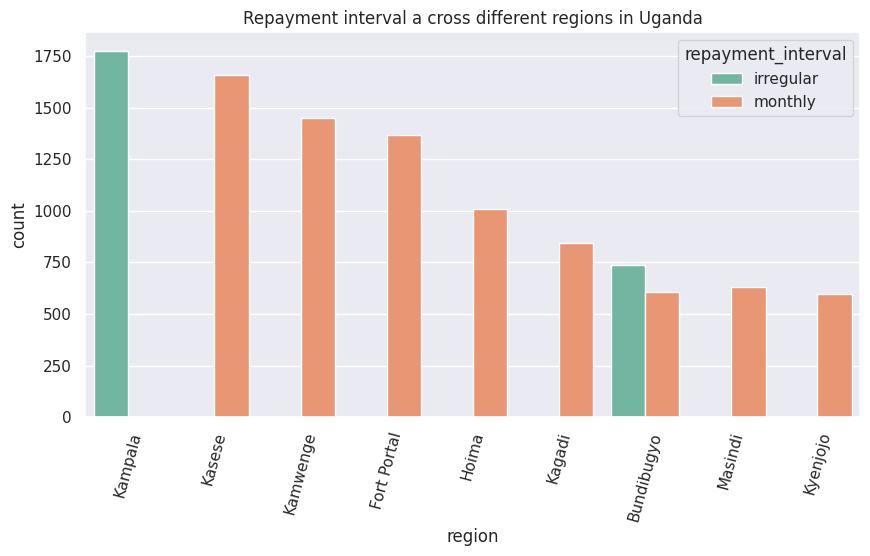

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='count',hue='repayment_interval',data=top10_repayment_interval_per_region,palette='Set2')
plt.title('Repayment interval a cross different regions in Uganda')
plt.xlabel('region')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#Generate boxplots to analyze loan amounts within sectors.

In [ ]:
uganda['sector'].value_counts()

,count
sector,
Food,4918
Agriculture,4619
Retail,3957
Education,1911
Clothing,1610
Housing,988
Services,988
Transportation,512
Personal Use,318


In [ ]:
loan_amount_within_sector=uganda.groupby('sector')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False)
loan_amount_within_sector.columns=['sector','loan_amount']
loan_amount_within_sector

,sector,loan_amount
0,Agriculture,3609350.0
6,Food,3287375.0
11,Retail,3036625.0
4,Education,1889875.0
2,Clothing,942650.0
8,Housing,756800.0
12,Services,695725.0
13,Transportation,358650.0
3,Construction,220150.0
7,Health,206525.0


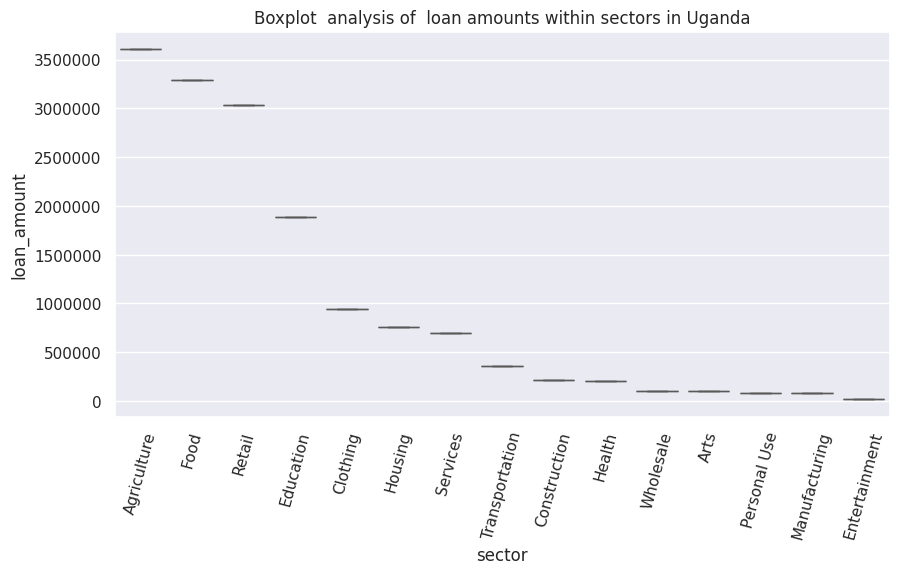

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='sector',y='loan_amount',data=loan_amount_within_sector,palette='Set2')
plt.title('Boxplot  analysis of  loan amounts within sectors in Uganda')
plt.xlabel('sector')
plt.ylabel('loan_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Classify loans by sector for the top 20 regions based on the top sectors.

In [ ]:
uganda['region'].value_counts().head(20)

,count
region,
Kampala,2149
Kasese,1989
Fort Portal,1944
Kamwenge,1724
Hoima,1360
Bundibugyo,1344
Kagadi,1028
Masindi,971
Kyenjojo,826


In [ ]:
uganda['sector'].value_counts().head(20)

,count
sector,
Food,4918
Agriculture,4619
Retail,3957
Education,1911
Clothing,1610
Housing,988
Services,988
Transportation,512
Personal Use,318


In [ ]:
df_region_sector=uganda.groupby('region')['sector'].value_counts().sort_values(ascending=False).head(20).reset_index(name='count')
df_region_sector

,region,sector,count
0,Kamwenge,Agriculture,807
1,Kampala,Food,725
2,Bundibugyo,Food,505
3,Fort Portal,Agriculture,489
4,Hoima,Food,481
5,Kasese,Retail,462
6,Kasese,Food,439
7,Kampala,Retail,436
8,Fort Portal,Food,413
9,Kagadi,Food,373


In [ ]:
# Calculate the value counts and convert the result to a DataFrame
#df_region_sector = uganda.groupby('region')['sector'].value_counts().sort_values(ascending=False).head(20).reset_index(name='count')

# plt.figure(figsize=(10,5))
# Use the new DataFrame 'df_region_sector' in the barplot
# sns.barplot(x='region', y='count', hue='sector', data=df_region_sector, palette='Set2')
# plt.title('Classify loans by sector for the top 20 regions based on the top sectors in Uganda')
# plt.xlabel('region')
# plt.ylabel('count')
# plt.xticks(rotation=75)
# plt.show()

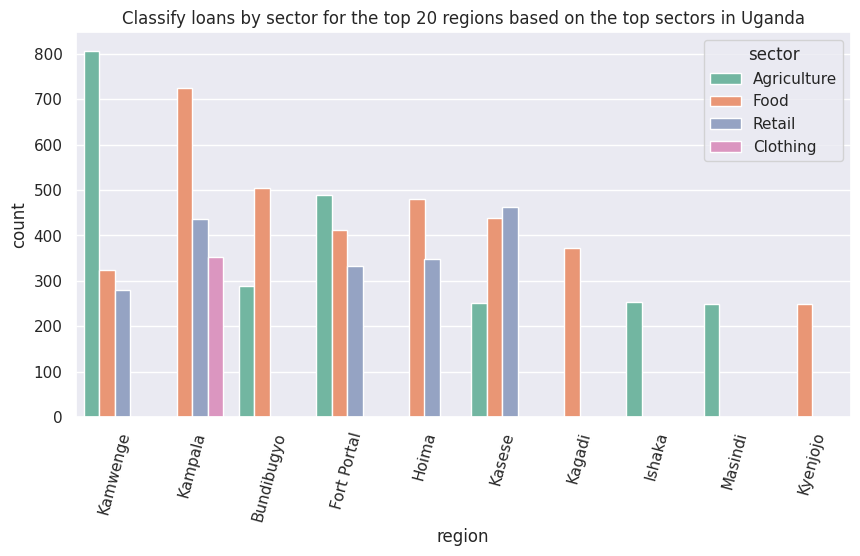

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='count',hue='sector',data=df_region_sector,palette='Set2')
plt.title('Classify loans by sector for the top 20 regions based on the top sectors in Uganda')
plt.xlabel('region')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#Determine the number of field partners per region (MPI dataset).

In [ ]:
uganda_2.columns

Index(['Partner ID', 'Field Partner Name', 'sector', 'Loan Theme ID',
       'Loan Theme Type', 'country', 'forkiva', 'region', 'geocode_old', 'ISO',
       'number', 'amount', 'LocationName', 'geocode', 'names', 'geo', 'lat',
       'lon', 'mpi_region', 'mpi_geo', 'rural_pct'],
      dtype='object')

In [ ]:
uganda_2['Field Partner Name'].value_counts()

,count
Field Partner Name,
UGAFODE Microfinance,103
BRAC Uganda,77
Impact Carbon,64
HOFOKAM,38
UpEnergy,9
Jibu,4
Micro Credit for Development and Transformation SACCO (MCDT SACCO),1
Youth Initiative for Community Empowerment,1
Yunus Social Business (YSB),1


In [ ]:
uganda_2.groupby('region')['Field Partner Name'].value_counts().sort_values(ascending=False).reset_index().head(20)

,region,Field Partner Name,count
0,Jinja,UGAFODE Microfinance,6
1,Kampala,UGAFODE Microfinance,6
2,Bombo Road,UGAFODE Microfinance,6
3,Rukungiri,UGAFODE Microfinance,6
4,Mpigi,UGAFODE Microfinance,5
5,Ibanda,UGAFODE Microfinance,5
6,Kyotera,UGAFODE Microfinance,5
7,Ishaka,UGAFODE Microfinance,5
8,Mbarara,UGAFODE Microfinance,5
9,Lyantonde,UGAFODE Microfinance,5


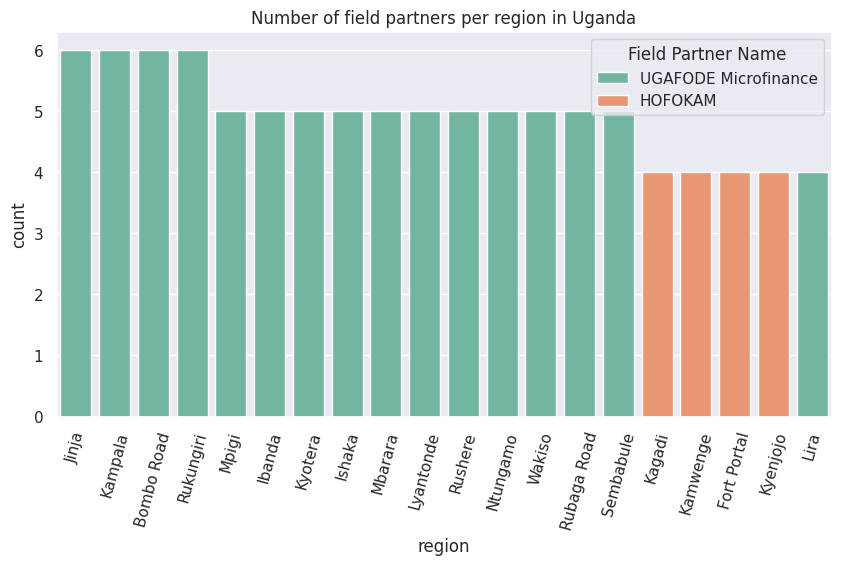

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='count',data=uganda_2.groupby('region')['Field Partner Name'].value_counts().sort_values(ascending=False).reset_index().head(20),palette='Set2',hue='Field Partner Name')
plt.title('Number of field partners per region in Uganda')
plt.xlabel('region')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()
#

#Visualize the number of loans per month.

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund', 'month'],
      dtype='object')

In [ ]:
uganda['date']=pd.to_datetime(uganda['date'])
uganda['date'].dt.month.value_counts()

,count
date,
6,2342
5,2104
3,1993
4,1857
1,1788
7,1762
8,1721
2,1711
10,1590


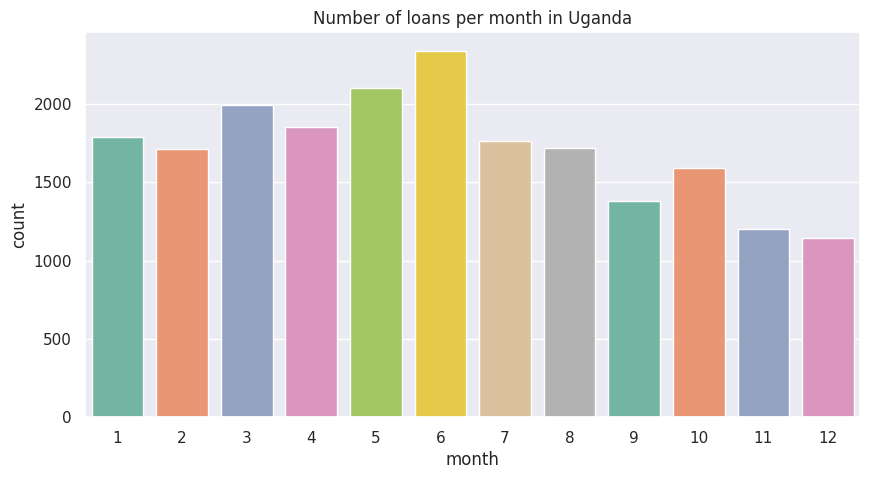

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=uganda['date'].dt.month.value_counts().index,y=uganda['date'].dt.month.value_counts().values,palette='Set2')
plt.title('Number of loans per month in Uganda')
plt.xlabel('month')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

#Calculate the number of regions.

In [ ]:
uganda['region'].nunique()

198

#Calculate the number of loans per region.

In [ ]:
uganda_loan_region=uganda.groupby('region')['id'].count().reset_index().sort_values(by='id',ascending=False).head(20)
uganda_loan_region.columns=['region','count']
uganda_loan_region

,region,count
61,Kampala,2149
68,Kasese,1989
35,Fort Portal,1944
63,Kamwenge,1724
39,Hoima,1360
21,Bundibugyo,1344
53,Kagadi,1028
119,Masindi,971
102,Kyenjojo,826
173,Rukungiri,473


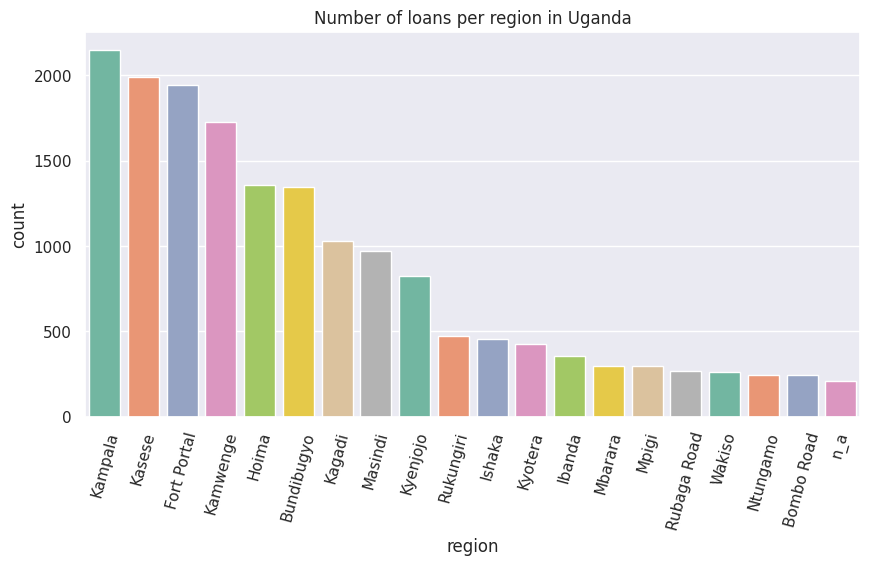

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='region',y='count',data=uganda_loan_region,palette='Set2')
plt.title('Number of loans per region in Uganda')
plt.xlabel('region')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

#Calculate the number of loans per sector.

In [ ]:
uganda['sector'].value_counts()

,count
sector,
Food,4918
Agriculture,4619
Retail,3957
Education,1911
Clothing,1610
Housing,988
Services,988
Transportation,512
Personal Use,318


In [ ]:
no_loan_per_sector=uganda.groupby('sector')['id'].count().reset_index().sort_values(by='id',ascending=False)
no_loan_per_sector.columns=['sector','count']
no_loan_per_sector

,sector,count
6,Food,4918
0,Agriculture,4619
11,Retail,3957
4,Education,1911
2,Clothing,1610
8,Housing,988
12,Services,988
13,Transportation,512
10,Personal Use,318
3,Construction,261


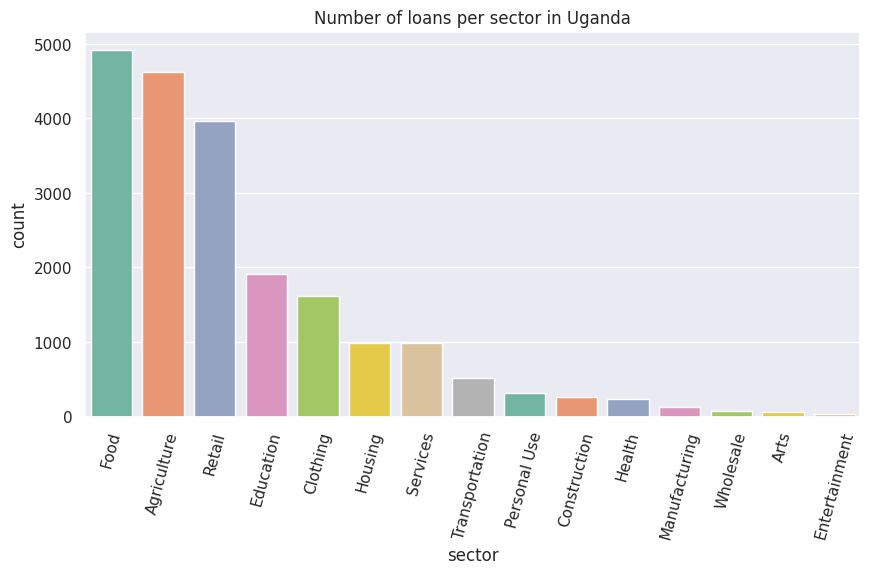

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='sector',y='count',data=no_loan_per_sector,palette='Set2')
plt.title('Number of loans per sector in Uganda')
plt.xlabel('sector')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()
#

#Analyze the distribution of disbursed times for loans.

In [ ]:
uganda['disbursed_time'].value_counts()

,count
disbursed_time,
2014-06-13 07:00:00+00:00,111
2014-06-20 07:00:00+00:00,93
2015-06-12 07:00:00+00:00,84
2014-07-16 07:00:00+00:00,81
2014-07-11 07:00:00+00:00,80
...,...
2016-03-26 07:00:00+00:00,1
2016-05-22 07:00:00+00:00,1
2016-05-08 07:00:00+00:00,1


In [ ]:
uganda['disbursed_time']=pd.to_datetime(uganda['disbursed_time'])
uganda['disbursed_time'].dt.month.value_counts().reset_index()

,disbursed_time,count
0,6,2279
1,5,2111
2,3,2085
3,4,2042
4,2,1839
5,1,1806
6,7,1725
7,8,1465
8,10,1424
9,9,1402


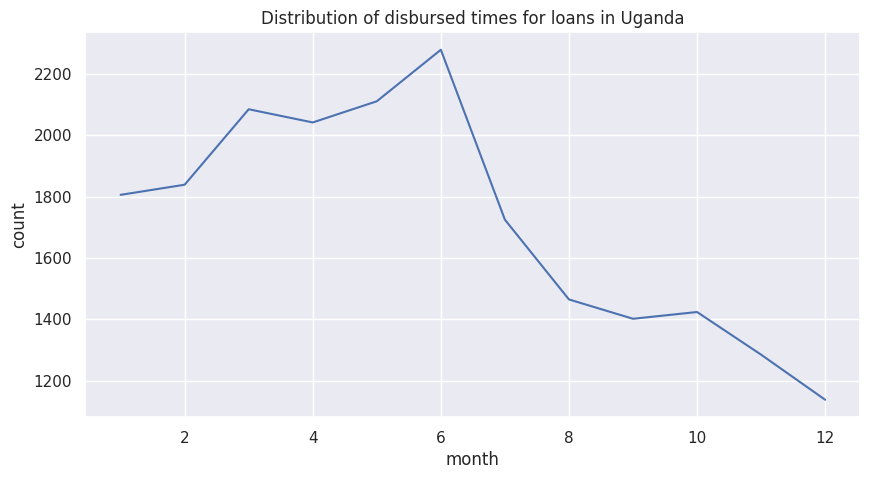

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=uganda['disbursed_time'].dt.month.value_counts().index,y=uganda['disbursed_time'].dt.month.value_counts().values,palette='Set2')
plt.title('Distribution of disbursed times for loans in Uganda')
plt.xlabel('month')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

#Plot a bar chart showing the total amount of loans per country.

In [ ]:
loan_total_per_country=kiva.groupby('country')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head(20)
loan_total_per_country

,country,loan_amount
59,Philippines,55342225.0
34,Kenya,34534300.0
80,United States,31496375.0
58,Peru,30867400.0
57,Paraguay,29629075.0
22,El Salvador,26603650.0
11,Cambodia,19872700.0
7,Bolivia,19843250.0
61,Rwanda,16646300.0
78,Uganda,15389350.0


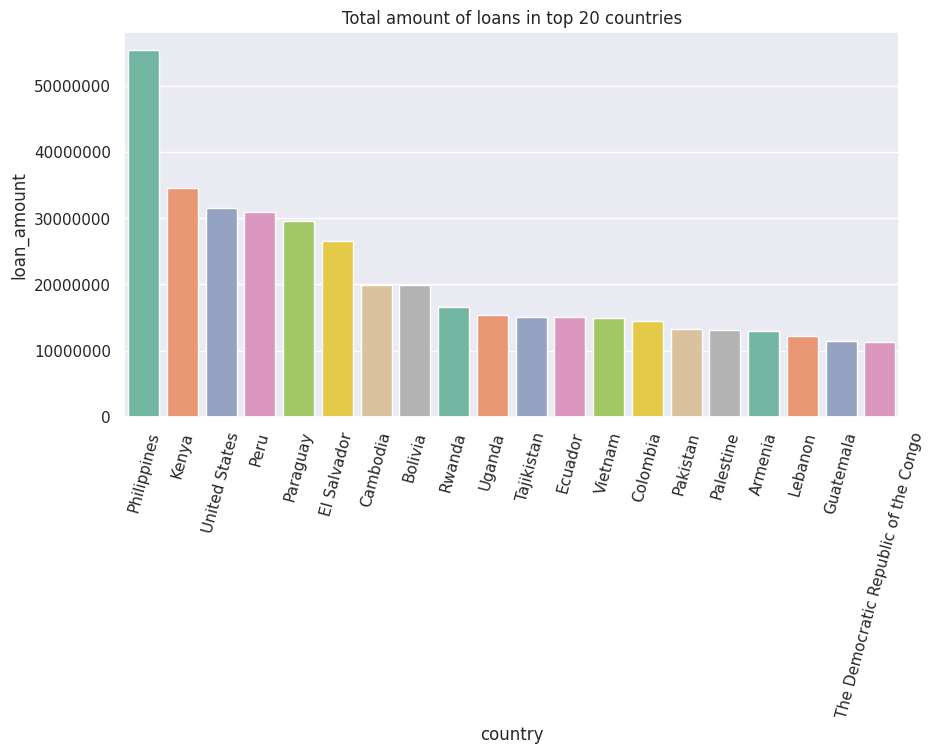

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='country',y='loan_amount',data=loan_total_per_country,palette='Set2')
plt.title('Total amount of loans in top 20 countries')
plt.xlabel('country')
plt.ylabel('loan_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()

#Plot a pie chart showing the distribution of loans across different sectors.

In [ ]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date', 'partner', 'main_gender', 'year', 'time_to_fund', 'month'],
      dtype='object')

In [ ]:
top5_loan_dist=uganda.groupby('sector')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False).head()
top5_loan_dist

,sector,loan_amount
0,Agriculture,3609350.0
6,Food,3287375.0
11,Retail,3036625.0
4,Education,1889875.0
2,Clothing,942650.0


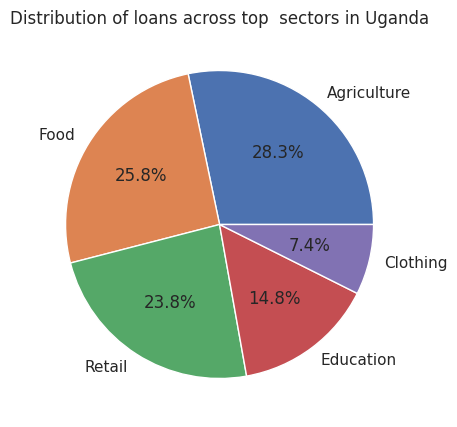

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(top5_loan_dist['loan_amount'],labels=top5_loan_dist['sector'],autopct='%1.1f%%')
plt.title('Distribution of loans across top  sectors in Uganda')
plt.show()
#

#Plot a time series graph showing the trend of loans disbursed over time.

In [ ]:
uganda['disbursed_time']=pd.to_datetime(uganda['disbursed_time'])
uganda['disbursed_time'].dt.year.value_counts().sort_index()

,count
disbursed_time,
2013,41
2014,7390
2015,6152
2016,4538
2017,2480


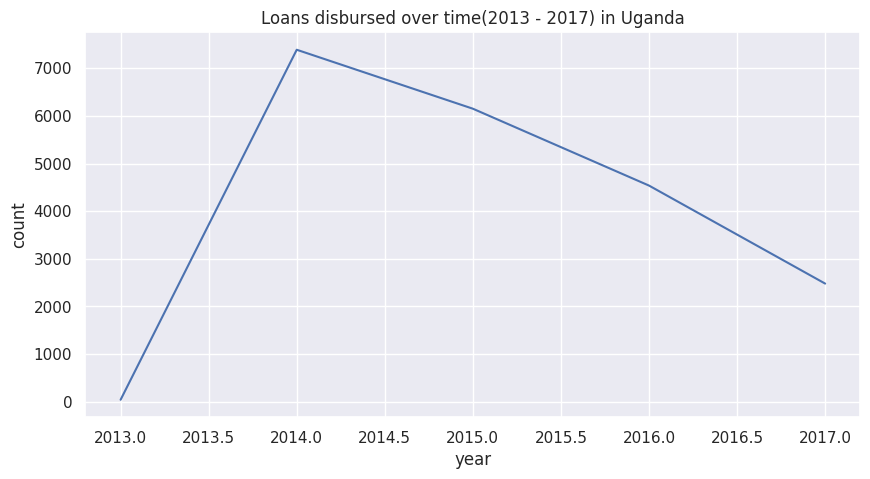

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=uganda['disbursed_time'].dt.year.value_counts().sort_index().index,y=uganda['disbursed_time'].dt.year.value_counts().sort_index().values,palette='Set2')
plt.title('Loans disbursed over time(2013 - 2017) in Uganda')
plt.xlabel('year')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()
#

In [ ]:
uganda['disbursed_time']=pd.to_datetime(uganda['disbursed_time'])
uganda['disbursed_time'].dt.month.value_counts().sort_index()
# uganda['disbursed_time'].dt.year.value_counts().sort_index()

,count
disbursed_time,
1,1806
2,1839
3,2085
4,2042
5,2111
6,2279
7,1725
8,1465
9,1402


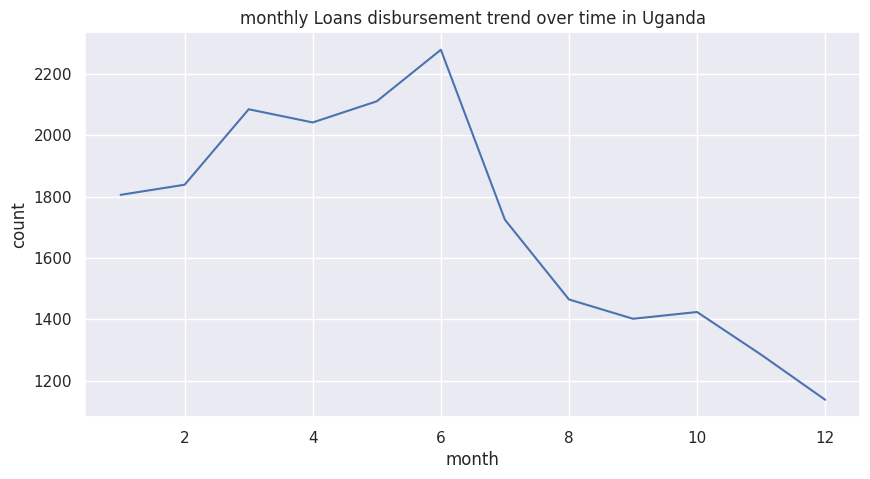

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=uganda['disbursed_time'].dt.month.value_counts().sort_index().index,y=uganda['disbursed_time'].dt.month.value_counts().sort_index().values,palette='Set')
plt.title('monthly Loans disbursement trend over time in Uganda')
plt.xlabel('month')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()
#

#Create a pie chart to visualize the proportion of male and female borrowers.

In [ ]:
uganda['main_gender'].value_counts()

,count
main_gender,
male,10866
female,9524


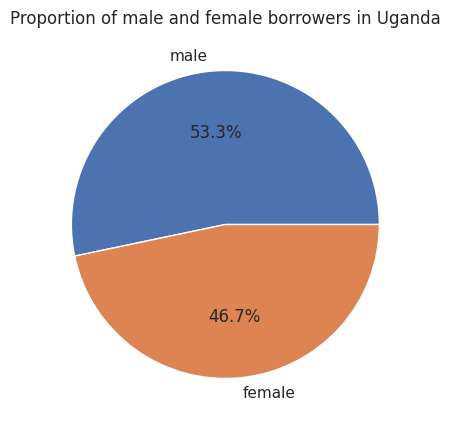

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(uganda['main_gender'].value_counts(),labels=uganda['main_gender'].value_counts().index,autopct='%1.1f%%')
plt.title('Proportion of male and female borrowers in Uganda')
plt.show()
#

#Create a scatter plot to visualize the correlation between the loan amount and term in months.

In [ ]:
uganda['loan_amount'].value_counts()

,count
loan_amount,
300.0,1075
600.0,888
150.0,699
200.0,657
575.0,647
...,...
5450.0,1
5875.0,1
5700.0,1


In [ ]:
uganda['term_in_months'].value_counts()

,count
term_in_months,
8.0,4285
14.0,4171
12.0,2272
10.0,2259
6.0,1505
7.0,1204
11.0,1117
9.0,879
13.0,538


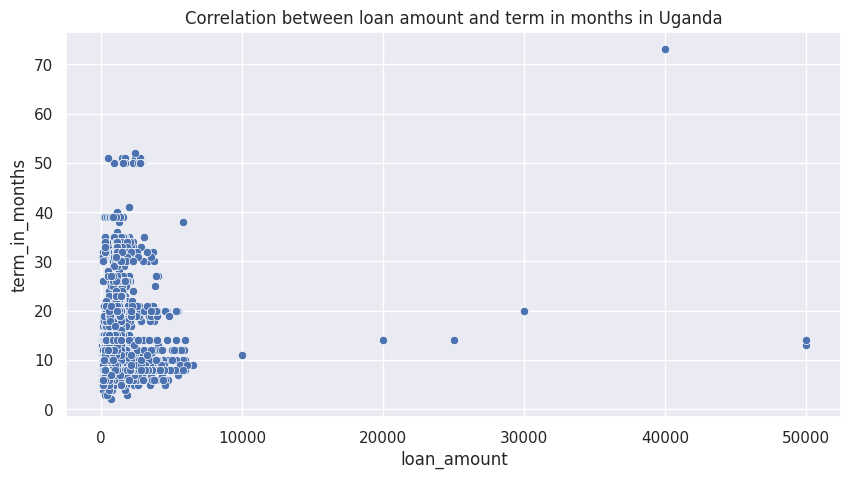

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='loan_amount',y='term_in_months',data=uganda,palette='Set2')
plt.title('Correlation between loan amount and term in months in Uganda')
plt.xlabel('loan_amount')
plt.ylabel('term_in_months')
plt.show()
#

#Create a box plot to show the variation in loan amounts across different sectors.

In [ ]:
uganda['sector'].value_counts()

,count
sector,
Food,4918
Agriculture,4619
Retail,3957
Education,1911
Clothing,1610
Housing,988
Services,988
Transportation,512
Personal Use,318


In [ ]:
loan_sector=uganda.groupby('sector')['loan_amount'].sum().reset_index().sort_values(by='loan_amount',ascending=False)
loan_sector

,sector,loan_amount
0,Agriculture,3609350.0
6,Food,3287375.0
11,Retail,3036625.0
4,Education,1889875.0
2,Clothing,942650.0
8,Housing,756800.0
12,Services,695725.0
13,Transportation,358650.0
3,Construction,220150.0
7,Health,206525.0


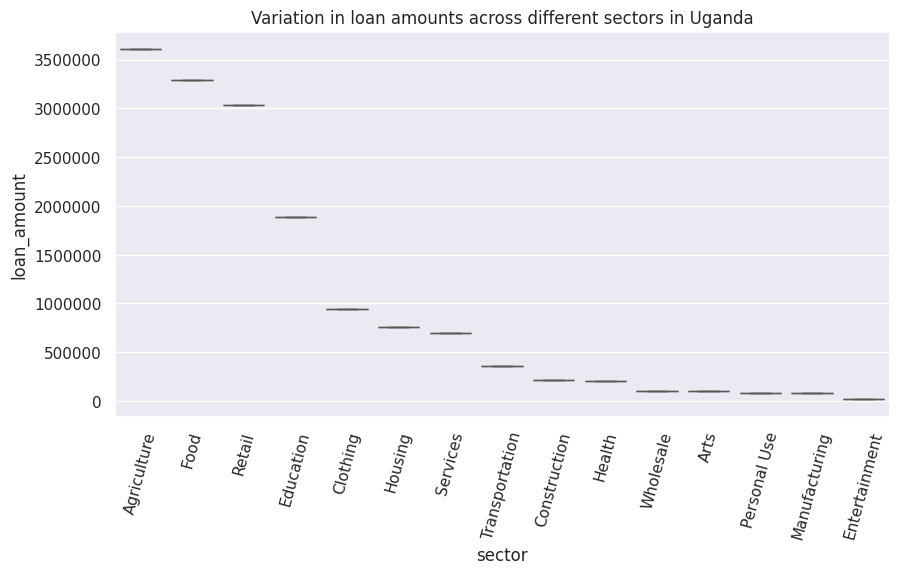

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='sector',y='loan_amount',data=loan_sector,palette='Set2')
plt.title('Variation in loan amounts across different sectors in Uganda')
plt.xlabel('sector')
plt.ylabel('loan_amount')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=75)
plt.show()
#

#Create a word cloud to visualize the most common words in loan description (use).

In [ ]:
#from wordcloud import WordCloud

In [ ]:
#uganda['use'].value_counts().drop('n_a')